In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
devtools::load_all("utils/modules/R/prstools")
library(data.table)
library(pROC)
library(reshape2)
library(bigstatsr)
library(ggplot2)
library(ggrastr)
library(ggrepel)
library(ggforce)
library(ggrepel)
source("scripts/post_hoc/utils.R")

# map from ENSEMBL to HGNC
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id
ensembl_to_pos <- (bridge$start_position + bridge$end_position)/2
names(ensembl_to_pos) <- bridge$ensembl_gene_id
ensembl_to_contig <- bridge$chromosome_name
names(ensembl_to_contig) <- bridge$ensembl_gene_id

i Loading gwastools

Loading required package: data.table

Loading required package: ggplot2

Loading required package: stringr

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/which_overlap.R

i Loading PRStools

Loading required package: bigsnpr

Loading required package: bigstatsr

Loading required package: bigassertr

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/prstools/R/which_overlap.R

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'reshape2'


The following objects are masked from 'package:data.table':

    dcast, melt




# Co-occurence

# 1.0 Aggregate SAIGE results

## 1.3 Common conditional analysis with NO prs

This is just to get an overview of the conditioning process.

In [54]:
# get phenotypes in which common markers have been used for conditioning
common_markers <- list.files("data/saige/output/binary/step2_common_cond/min_mac4", pattern = "markers")
phenotypes_with_common_markers <- stringr::str_extract(common_markers, "chr[0-9]+_([a-z]|[A-Z]|[0-9]|\\_)+pLoF")
phenotypes_with_common_markers <- gsub('(chr[0-9]+_)|(_pLoF)','', phenotypes_with_common_markers)

# make sure that these match with spa iter files
spa_iter_paths_full <- list.files("data/conditional/common/spa_iter", pattern = "markers", full.names = TRUE)
spa_iter_paths <- basename(spa_iter_paths_full)
phenotypes <- stringr::str_extract(spa_iter_paths, "200k_([a-z]|[A-Z]|[0-9]|\\_)+pLoF")
phenotypes <- gsub('(200k_)|(_pLoF)','', phenotypes)
stopifnot(all(phenotypes %in% phenotypes_with_common_markers))
stopifnot(all(phenotypes_with_common_markers %in% phenotypes))
genes <- stringr::str_extract(spa_iter_paths, "([A-Z]|[0-9])+.markers")
genes <- gsub(".markers","", genes)
spa_dt <- data.table(phenotypes, genes, spa_iter_paths_full)

spa_full <- do.call(rbind, lapply(1:nrow(spa_dt), function(idx){
    gene <- spa_dt$genes[idx]
    path <- spa_dt$spa_iter_paths_full[idx]
    d <- fread(path)
    colnames(d) <- c("iteration", "marker", "marker_type","p.value","p.value_cutoff", "phenotype", "all_markers")
    d <- cbind(gene, d)
    d <- d[,c("phenotype", "gene", "marker", "iteration","p.value","p.value_cutoff", "all_markers")]
    return(d)
}))

# write table with conditioniong steps
spa_full$id <- paste0(spa_full$gene, "_", spa_full$phenotype)
fwrite(spa_full, "data/post_hoc/results/spa_iter_no_prs_steps.txt", sep = "\t", quote = FALSE, na = "NA")

ERROR: Error: all(phenotypes %in% phenotypes_with_common_markers) is not TRUE


In [207]:
# get common files
targets <- paste0("ukb_eur_wes_200k_",phenotypes, "_pLoF_damaging_missense.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2_common_cond_no_prs/min_mac4"
files_common <- file.path(directory, targets)
lst_common <- lapply(files_common, read_files)
dt_common <- do.call(rbind, lst_common)
# subset to the genes we are interested in                       
dt_common$id <- paste0(dt_common$MarkerID,"_",dt_common$phenotype)
dt_common <- dt_common[dt_common$id %in% spa_full$id,]
dt_common$id <- NULL

In [208]:
# get common prs files
targets <- paste0("ukb_eur_wes_200k_",phenotypes, "_pLoF_damaging_missense_locoprs.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2_common_cond/min_mac4"
files_prs_common <- file.path(directory, targets)
lst_prs_common <- lapply(files_prs_common, read_files)
dt_prs_common <- do.call(rbind, lst_prs_common)
# subset to the genes we are interested in                       
dt_prs_common$id <- paste0(dt_prs_common$MarkerID,"_",dt_prs_common$phenotype)
dt_prs_common <- dt_prs_common[dt_prs_common$id %in% spa_full$id,]
dt_prs_common <- dt_prs_common[dt_prs_common$prs == TRUE,]
dt_prs_common$id <- NULL

In [105]:
regexify_varid <- function(v) return(paste0("(^",v,"$)|(^",v,";)|(;",v,";)|(;",v,"$)"))

In [142]:
genes <- unique(d$gene_id)

for (g in genes){
    
    write(paste("Running", g, args$chromosome), stderr())
    d_gene <- d[d$gene_id %in% g,]
    varids <- unique(unlist(strsplit(d$varid, split = ";")))
    haplotypes <- c("chet","hom","cis") #, "opposite")
    out <- do.call(rbind, lapply(haplotypes, function(h){
        if (h == "chet"){
            d_gene_hap <- d_gene[d_gene$is_chet | d_gene$is_hom,]
        } else if (h == "hom"){
            d_gene_hap <- d_gene[d_gene$is_hom,]
        } else if (h == "cis"){
            d_gene_hap <- d_gene[d_gene$is_cis,]
        }
        # iterate over variants either co-occuring on the same
        # haplotype or oppoposite haplotypes
        if (nrow(d_gene_hap) > 0){
            do.call(rbind, lapply(varids, function(v1){
                re_v1 <- regexify_varid(v1)
                v1_in_d <- grepl(re_v1, d_gene_hap$varid)
                do.call(rbind, lapply(varids, function(v2){    
                    # if the variant is the same it must
                    # be the same row being counted or a homozygote
                    if ((v1 != v2) | (h == "hom")){
                        re_v2 <- regexify_varid(v2)
                        v2_in_d <- grepl(re_v2, d_gene_hap$varid)
                        occ <- data.table(table(v2_in_d, v1_in_d))
                        occ$v1 <- v1 
                        occ$v2 <- v2
                        occ$g <- g
                        occ$haplotype <- h
                        # only keep those where both variants
                        # are present
                        occ <- occ[(occ$v1_in_d == TRUE) &
                                   (occ$v2_in_d == TRUE)]
                        occ$v2_in_d <- NULL
                        occ$v1_in_d <- NULL
                        return(occ)
                    }
                   
                }))
            }))
        
        }
 
    })) 
    outfile <- paste0(args$out_prefix,"_", g,".txt.gz")
    fwrite(out, outfile, sep = "\t")
}




In [143]:
out

N,v1,v2,g,haplotype
<int>,<chr>,<chr>,<chr>,<chr>
1,chr21:32337409:A:ACGCTGAGAGTGGCGCCATAGGCCCCGAGAAG,chr21:32337409:A:ACGCTGAGAGTGGCGCCATAGGCCCCGAGAAG,ENSG00000142207,hom


In [219]:
# combine with and without PRS
dt_common_combined <- rbind(dt_common, dt_prs_common)
dt_common_combined <- dt_common_combined[order(dt_common_combined$phenotype),]
colnames(dt_common_combined)[1:25] <- new_saige_cols_c
dt_common_combined <- cbind(phenotype=dt_common_combined$phenotype, dt_common_combined[,-c("phenotype")])

fwrite(dt_common_combined, "data/post_hoc/results/spa_cond_prs_common.txt", sep = '\t', quote = FALSE, na = "NA")

In [220]:
d <- fread("data/prs/scores/BC_combined_pgs.txt.gz")

In [223]:
d <- fread("data/knockouts/alt/pp90/recoded_syn/ukb_eur_wes_200k_chr22.pp90.recoded.synonymous.txt.gz")

In [227]:
samples <- unique(d$s)
length(samples)

[1] 176587

In [128]:
out

N,v1,v2,g,haplotype
<int>,<chr>,<chr>,<chr>,<chr>
1,chr21:36231026:G:T,chr21:36237282:G:A,ENSG00000142197,chet
1,chr21:36237282:G:A,chr21:36231026:G:T,ENSG00000142197,chet


In [118]:
get_path_phenotype("CAD_combined", "data/saige/output/binary/step2/min_mac4/")

data/saige/output/binary/step2/min_mac4//ukb_eur_wes_200k_CAD_combiffned_pLoF_damaging_missense.txt.gz does not exist (with or without PRS). Skipping


In [107]:
lapply(lst, head)

CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,,N_case,N_ctrl,BETA_c,SE_c,Tstat_c,var_c,p.value_c,p.value.NA_c,phenotype,prs
<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
chr1,13,ENSG00000007933,RCoW,nAsl,12,3.56551e-05,0,-0.502454,3.67719,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,19,ENSG00000009709,JGMf,Xpdi,6,1.78275e-05,0,-0.501609,6.35609,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,30,ENSG00000014914,fYaR,QXNf,50,1.48563e-04,0,-0.502382,1.93159,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,43,ENSG00000027644,YkDw,oTNs,10,2.97126e-05,0,-0.503412,3.52412,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,53,ENSG00000041988,iKje,KQJO,16,4.75401e-05,0,-0.502448,3.40791,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,54,ENSG00000042781,ONNp,MqOu,36,1.06965e-04,0,-0.502243,2.31938,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,⋯,N_case,N_ctrl,BETA_c,SE_c,Tstat_c,var_c,p.value_c,p.value.NA_c,phenotype,prs
<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
chr1,13,ENSG00000007933,RCoW,nAsl,12,3.56551e-05,0,-0.502454,3.67719,⋯,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE


In [256]:
dt <- dt[dt$p.value < (0.05 / (320*2000)),]
dt <- dt[(dt$AC_Allele2 >= 8) & (dt$N_case_hom >= 2),]
dt <- dt[order(dt$p.value),]

In [257]:
options(repr.matrix.max.cols=200, repr.matrix.max.rows=400)
head(dt, n = 400)

CHR,POS,ensembl_gene_id,Pseudo_allele1,Pseudo_allele2,KO_count,KO_freq,MissingRate,BETA,SE,Tstat,var,p.value,p.value.NA,Is.SPA,KO_freq_case,KO_freq_ctrl,N_case,N_ctrl,N_case_ko,N_ctrl_ko,phenotype
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>


# Manhatten plots

In [72]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
devtools::load_all("utils/modules/R/prstools")
require(ggplot2)
require(ggrepel)
require(tidyverse)
require(data.table)

i Loading gwastools

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/which_overlap.R

i Loading PRStools

Loading required package: bigsnpr

Loading required package: bigassertr

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/prstools/R/which_overlap.R



In [3]:
process_saige_df <- function(d, f){
    # deal with conditional P-values
    if ("p.value_c" %in% colnames(d)) {
        d$p.value <- d$p.value_c
        d$p.value.NA <- d$p.value.NA_c
        d$BETA <- d$BETA_c
        d$SE <- d$SE_c
        d$Tstat <- d$Tstat_c
        d$var <- d$var_c
    }
    
    # 
    d$p.value <- as.numeric(d$p.value)
    d$p.value.NA <- as.numeric(d$p.value.NA)
    d$BETA <- as.numeric(d$BETA)
    d$SE <- as.numeric(d$SE)

    d$ensembl_gene_id <- d$MarkerID
    d$ensembl_gene_id[!grepl("ENSG", d$ensembl_gene_id)] <- NA
    d$pvalue = d$p.value
    d$prs <- ifelse(grepl("locoprs", f),"With PRS", "Without PRS")
    d$analysis <- basename(f)
    d$analysis <- stringr::str_extract(d$analysis, "200k_.+pLoF_damaging_missense")
    d$analysis <- gsub("200k_", "", d$analysis)
    d$analysis <- gsub("_pLoF_damaging_missense", "", d$analysis)
    d$phenotype <- d$analysis

    # add hgnc and grch38 position
    d$hgnc_symbol <- ensembl_to_hgnc[d$ensembl_gene_id]
    d$contig <- ensembl_to_contig[d$ensembl_gene_id]
    d$pos <- ensembl_to_pos[d$ensembl_gene_id]
    d$N_ko_case <- d$N_case_hom #unlist(ifelse("N_ko_case" %in% colnames(d), list(d$N_case_hom), NA))
    d$N_ko_ctrl <- d$N_ctrl_hom #unlist(ifelse("N_ko_ctrl" %in% colnames(d), list(d$N_ctrl_hom), NA))
    d$N_ko <- d$AC_Allele2/2
    d$KF_ko <- d$AF_Allele2
    d$KF_case <- d$AF_case
    d$KF_ctrl <- d$AF_ctrl
    return(d)
}


get_formatted_df <- function(files){
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        d <- fread(f)
        if (is.numeric(d$p.value)){
            if (nrow(d) > 0){
                return(process_saige_df(d, f))
            } else {
                return(NULL)
            }
        } else {
            write(paste0(f, "was excluded because p-value col was invalid."), stderr())   
        }
    }))
    return(d)
}

In [4]:
# get all files we need to iterate over
files <- list(
    files_none_no_prs = list_files_saige(cond = "none", prs = "exclude"),
    files_none_prs = list_files_saige(cond = "none", prs = "only"),
    files_common_no_prs = list_files_saige(cond = "common", prs = "exclude"),
    files_common_prs = list_files_saige(cond = "common", prs = "only"),
    files_rare_no_prs = list_files_saige(cond = "rare", prs = "exclude"),
    files_rare_prs = list_files_saige(cond = "rare", prs = "only"),
    files_combined_prs = list_files_saige(cond = "combined", prs = "only"),
    files_combined_no_prs = list_files_saige(cond = "combined", prs = "exclude")
)


#files <- list(
#    files_none = list_files_saige(cond = "none", prs = "exclude"),
#    files_common = list_files_saige(cond = "common", prs = "exclude"),
#    files_rare = list_files_saige(cond = "rare", prs = "exclude"),
#    files_combined = list_files_saige(cond = "combined", prs = "only")
#)

header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
head(header)

ERROR: Error in list_files_saige(cond = "none", prs = "exclude"): could not find function "list_files_saige"


In [195]:
length(unique(header))
length(unique())

[1] 313

# Post-hoc analysis of significant gene-phenotypes

In [14]:
# get ICD information
library(paletteer)
icd <- fread("data/phenotypes/phenotype_icd_chapter.txt")
icd <- icd[order(icd$ICD_chapter),]
na_chapter <- "None of the above"
icd[is.na(icd$ICD_chapter_desc_short)]$ICD_chapter_desc_short <- na_chapter 
chapters <- unique(icd$ICD_chapter_desc_short)

In [15]:
# get data
d <- fread("data/post_hoc/results/176k_saige_cond_sig_subset_prefer_prs.txt.gz")
d$phenotype <- gsub("chr[0-9]+\\_","",d$phenotype)
d <- d[d$p.value < (0.05 / (311 * 1143)),]
d <- d[d$N_ko_case >= 2]
d$hgnc_symbol[d$hgnc_symbol == "n/a"] <- NA
nrow(d)

[1] 71

In [21]:
omim <- fread("data/knockouts/tables/230117_evidence.omim.txt.gz")
gencc <- fread("data/knockouts/tables/230117_evidence.gencc.txt.gz")
gtex <- fread("derived/tables/gtex_top10.txt.gz")

In [23]:
head(gtex)

gene_id,hgnc_symbol,tissues
<chr>,<chr>,<chr>
ENSG00000000419,DPM1,Adrenal_Gland;Cells_EBV_transformed_lymphocytes;Cells_Transformed_fibroblasts;Heart_Left_Ventricle
ENSG00000000457,SCYL3,Bladder;Breast_Mammary_Tissue;Cervix_Ectocervix;Cervix_Endocervix;Colon_Transverse;Minor_Salivary_Gland;Nerve_Tibial;Prostate;Skin_Sun_Exposed_Lower_leg;Stomach;Thyroid
ENSG00000000460,C1orf112,Cells_EBV_transformed_lymphocytes;Nerve_Tibial
ENSG00000000938,FGR,Cells_EBV_transformed_lymphocytes;Lung;Spleen;Whole_Blood
ENSG00000000971,CFH,Adipose_Subcutaneous;Artery_Aorta;Artery_Coronary;Artery_Tibial;Heart_Atrial_Appendage;Liver;Minor_Salivary_Gland;Nerve_Tibial;Ovary
ENSG00000001036,FUCA2,Adipose_Subcutaneous;Adipose_Visceral_Omentum;Adrenal_Gland;Breast_Mammary_Tissue;Cells_Transformed_fibroblasts;Cervix_Endocervix;Colon_Transverse;Fallopian_Tube;Kidney_Cortex;Lung;Small_Intestine_Terminal_Ileum;Stomach


In [413]:
# get data
d <- fread("data/post_hoc/results/1")
d$phenotype <- gsub("chr[0-9]+\\_","",d$phenotype)
d <- d[d$p.value < (0.05 / (313 * 1143)),]
d <- d[d$N_ko_case >= 2]
d$hgnc_symbol[d$hgnc_symbol == "n/a"] <- NA

# setup sizes 
breaks <- c(0,2, 5,Inf)
labels <- c("2","3-5","6+")
d$N_ko_case_bin <- cut(d$N_ko_case, breaks = breaks, labels=labels)

# combine with ICD
d <- d[,c("phenotype", "CHR", "MarkerID", "hgnc_symbol", "p.value", "BETA", "SE")]
d <- merge(icd, d,  by.y = "phenotype", by.x = "unix_code", all.y = TRUE)
d$ICD_chapter_desc[is.na(d$ICD_chapter_desc)] <- na_chapter
d$ICD_chapter_desc_short[is.na(d$ICD_chapter_desc_short)] <- na_chapter
d$ICD_chapter_desc_short <- NULL
d$ICD_chapter <- NULL
d$unix_code <- NULL
colnames(d)[colnames(d) == "MarkerID"] <- "ensembl_gene_id"

In [414]:
# load hgncid to ensembl mapping ---------
bridge <- fread(args$path_bridge)
bridge <- bridge[bridge$hgnc_symbol != "",]
hgncid_to_ensembl <- bridge$ensembl_gene_id
names(hgncid_to_ensembl) <- bridge$hgnc_id
hgnc_to_ensembl <- bridge$ensembl_gene_id
names(hgnc_to_ensembl) <- bridge$hgnc_symbol

# load genCC columns and subset ----------
gencc <- fread(args$path_gencc)
cols_to_keep <- c("uuid","gene_curie","gene_symbol", "disease_title", "disease_original_title",
                  "classification_title", "moi_curie", "moi_title", "disease_original_curie")
gencc <- gencc[,colnames(gencc) %in% cols_to_keep,,with=FALSE]
gencc$ensembl_gene_id <- hgncid_to_ensembl[gencc$gene_curie]
colnames(gencc)[1:9] <- paste0("gencc.",colnames(gencc)[1:9])
gencc$hgnc_symbol <- gencc$gencc.gene_symbol
gencc$gencc.gene_symbol <- NULL

In [544]:
# read omim lines -------- 
lines <- readLines("/well/lindgren/flassen/ressources/genesets/genesets/data/omim/morbidmap.txt")
lines <- readLines(args$path_omim)
lines <- lines[!grepl("^\\#", lines)]
#genes_to_find <- unique(na.omit(d$hgnc_symbol))
genes_to_find <- unique(bridge$hgnc_symbol)
omim_entry <- rbindlist(lapply(genes_to_find, function(g) {
    line <- lines[grepl(g, lines)]
    if (length(line) > 0){
        # create lines of all matches with gene name
        line_list <- strsplit(line, split = "\t")
        omim_lines <- data.table(do.call(rbind, line_list))
        omim_lines$gene <- g
        all_genes <- strsplit(gsub(" ", "",omim_lines$V2), split = ",")
        # ensure that full gene name appear in line
        lines_to_keep <- unlist(lapply(all_genes, function(line) g %in% line))
        omim_lines <- omim_lines[lines_to_keep,]                     
        if (any(lines_to_keep)){
            return(omim_lines)
        } else {
            return(NULL)
        }
    }
}))

# prettify and ready to combine
colnames(omim_entry) <- c("phenotype", "gene_symbols", "mim", "cyto_loc", "hgnc_symbol")
omim_entry$cyto_loc <- NULL # don't need location
omim_entry$mim <- NULL # don't need omim gene id
genes <- unique(omim_entry$hgnc_symbol)

In [545]:
# combine omim lines to one gene per line ----------
omim <- do.call(rbind, lapply(genes, function(g){
    g_omim <- omim_entry[omim_entry$hgnc_symbol == g,]
    # grab genes that are involved in all phenotypes
    genes_involved <- unlist(strsplit(paste(g_omim$gene_symbols, collapse = ", "), split = ", "))
    genes_involved <- sort(unique(genes_involved))
    # grab disease omim IDs
    mims <- unique(na.omit(stringr::str_extract(g_omim$phenotype, "[0-9]{4,10}+")))
    phenotype <- gsub("\\,\\ [0-9]+","",g_omim$phenotype)
    phenotype <- gsub("\\ \\([0-9]\\)", "", phenotype)
    phenotype <- unique(phenotype)
    # combine
    return(data.table(
        hgnc_symbol = g,
        ensembl_gene_id = hgnc_to_ensembl[g],
        phenotypes = paste(phenotype, collapse = "; "),
        mims = paste(mims, collapse = "; "),
       genes = paste(genes_involved, collapse = "; ")
    ))
}))

colnames(omim)[3:5] <- c("omim.phenotypes","omim.mim","omim.genes")

In [419]:
by <- c("hgnc_symbol","ensembl_gene_id")
combined <- merge(merge(d, omim, by = by, all.x=TRUE), gencc, by = by, all.x=TRUE)

In [393]:
fwrite(combined, "derived/tables/230117_omim_gencc_sig_hits.txt", sep = "\t")

In [420]:
combined[is.na(combined$omim.phenotypes),]

hgnc_symbol,ensembl_gene_id,phenotype,ICD_chapter_desc,CHR,p.value,BETA,SE,omim.phenotypes,omim.mim,omim.genes,gencc.uuid,gencc.gene_curie,gencc.disease_title,gencc.disease_original_curie,gencc.disease_original_title,gencc.classification_title,gencc.moi_curie,gencc.moi_title
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NA,ENSG00000251569,Multiple sclerosis,Nervous,chr2,5.383054e-24,26.71070,2.643960,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ADGRE1,ENSG00000174837,Acute Kidney Injury,Genitourinary,chr19,4.988747e-35,39.28040,3.181090,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ALDH1L1,ENSG00000144908,Psoriatic arthropathy,Musculoskeletal and connective tissue,chr3,4.287916e-08,7.91557,1.444820,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ANO7,ENSG00000146205,End stage renal disease,Multiple,chr2,1.231623e-23,26.47510,2.641940,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
AQP6,ENSG00000086159,Anterior and Intermediate Uveitis,"Eye, adnexa, ear, and mastoid",chr12,9.326851e-17,17.98390,2.163340,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ATP4A,ENSG00000105675,Bell's palsy,Nervous,chr19,1.274461e-07,5.34042,1.010970,NA,NA,NA,GENCC_000110-HGNC_819-Orphanet_464756-HP_0000007-GENCC_100009,HGNC:819,familial gastric type 1 neuroendocrine tumor,Orphanet:464756,Orphanet:464756,Supportive,HP:0000007,Autosomal recessive
ATP4A,ENSG00000105675,Bell's palsy,Nervous,chr19,1.274461e-07,5.34042,1.010970,NA,NA,NA,GENCC_000101-HGNC_819-MONDO_0003111-HP_0000007-GENCC_100004,HGNC:819,gastric neuroendocrine neoplasm,MONDO:0003111,gastric neuroendocrine neoplasm,Limited,HP:0000007,Autosomal recessive
C18orf25,ENSG00000152242,Acute Kidney Injury,Genitourinary,chr18,4.173525e-22,24.21970,2.505460,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
CAPN2,ENSG00000162909,Trigeminal neuralgia,Nervous,chr1,4.998478e-10,7.02919,1.130250,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


# Power calculations

In [13]:
path_header <- "data/phenotypes/dec22_phenotypes_binary_200k_header.tsv"
path_phenotypes <- "data/phenotypes/dec22_phenotypes_binary_200k.tsv.gz"
header <- readLines(path_header)
dt <- fread(path_phenotypes)
dt <- dt[,colnames(dt) %in% header, with=FALSE]

In [19]:
colsums <- colSums(dt, na.rm = TRUE)

In [118]:
sum(colsums < 199) # 38 phenotypes

[1] 38

In [30]:
case_quantiles <- quantile(colSums(dt, na.rm = TRUE))
case_quantiles

0%   25%   50%   75%  100% 
   51   322   904  3576 86077

In [21]:
ps = 0.05 / (313 * 1143)
power = 0.80

In [81]:
beta_power_curve

function(cases, controls, length.out = 500,
                             pw.thresh = 0.8, p.threshold = 0.05, 
                             maf_lower = 3/175000, maf_upper = 0.05,
                             beta_lower = 0, beta_upper = 100){
    
    
    stopifnot(maf_lower < maf_upper)
    stopifnot(beta_lower < beta_upper)
    q = qchisq(p.threshold, df = 1, lower = F) #chi-square value corresp. significance threshold
    f = seq(maf_lower, maf_upper, length = length.out)
    b = seq(beta_lower, beta_upper, length = length.out)
    
    pw = rep(NA, length(b)) #power at each candidate b
    b.for.f = rep(NA,length(f)) #for each f gives the b value that leads to target power
    for(i in 1:length(f)){ 
        ncp = cases*controls / (cases+controls)*2*f[i]*(1-f[i])*b^2
        pw = pchisq(q, df = 1, ncp = ncp, lower = F)
        b.for.f[i] = suppressWarnings(b[ min( which(pw > pw.thresh) ) ])
    }
    return(data.table(f=f, beta.for.f=b.for.f))
}
<bytecode: 0x56382dcaf278>
<environment: namespace:gwastools>

In [46]:
generate_power_curves <- function(cases, n_samples, s, power, length.out=1500){
    do.call(rbind, lapply(cases, function(cur_cases){
        curve <- beta_power_curve(
            cur_cases, 
            n_samples-cur_cases, 
            p.threshold = ps, 
            pw.thresh = power, 
            length.out = length.out
        )
        curve$cases <- cur_cases
        return(curve)
    }))
}

In [151]:
curves <- generate_power_curves(c(100,200,500,1000), 176000, ps, power, length.out=2000)

In [182]:
curves$cases <- factor(curves$cases)
curves$label <- paste0("Number of cases = ", curves$cases)

In [178]:
# axes
n_total <- 100000
people <- c(1, 3, 9, 25, 100, 500)
values <- people / n_total
labels <- paste(people)
labels

[1] "1"   "3"   "9"   "25"  "100" "500"

In [184]:
# simple solve to get f from beta.for.f
categories <- unique(curves$cases)
yintercepts <- unlist(lapply(categories, function(cat){
    curves_subset <- curves[curves$cases %in% cat,]
    index <- which(floor(curves_subset$beta.for.f) == 10)
    index <- index[length(index)]
    return(curves_subset$f[index])
}))

line_df <- data.table(y=yintercepts, cases=categories)
line_df$label <- paste0("Number of cases = ", line_df$cases)

Warning message:
"Removed 1 row containing missing values
(`geom_line()`)."


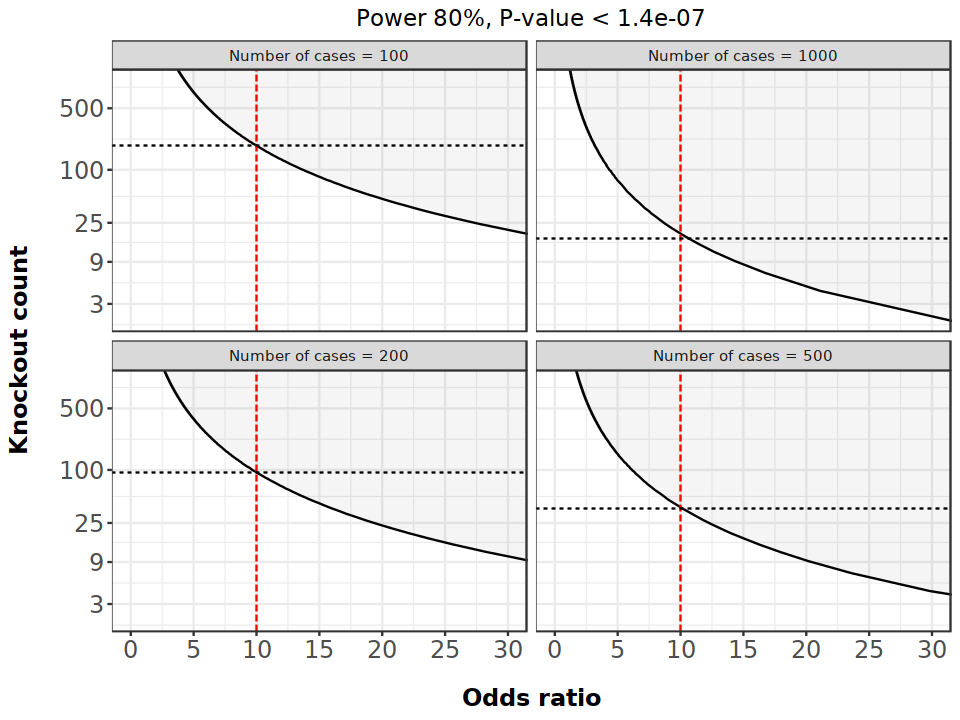

In [192]:
options(repr.plot.width=8, repr.plot.height=6)
ggplot(curves, aes(x=beta.for.f, y=log10(f), labels = cases)) +
    geom_line() + 
    geom_ribbon(data=curves, aes(ymax=log10(f), ymin=0), alpha=0.05, fill="grey30") +
    geom_vline(xintercept = 10, linetype = 'longdash', color = 'red') +
    geom_hline(data = line_df, aes(yintercept = log10(y)), linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=log10(values), labels = labels) +
    coord_cartesian(
        ylim=log10(c(4/200000, 2000/200000)),
        xlim=c(0, 30)
    ) +
    xlab("Odds ratio") +
    ylab("Knockout count") +
    ggtitle(paste("Power 80%, P-value <",formatC(ps, format = "e", digits = 1))) +
    facet_wrap(~label, nrow = 2, ncol=2) +
    theme_bw() +
    theme(
        legend.position="right",
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.text=element_text(size=15)
    )


In [194]:
outfile <- "derived/plots/230120_knockout_power_analysis.pdf"
ggsave(outfile, width = 8 , height = 6)

Warning message:
"Removed 1 row containing missing values
(`geom_line()`)."


# Power smile plot

In [5]:
# get ICD information
library(paletteer)
icd <- fread("data/phenotypes/phenotype_icd_chapter.txt")
icd <- icd[order(icd$ICD_chapter),]
na_chapter <- "None of the above"
icd[is.na(icd$ICD_chapter_desc_short)]$ICD_chapter_desc_short <- na_chapter 
chapters <- unique(icd$ICD_chapter_desc_short)

In [6]:
# get data
d <- fread("data/post_hoc/results/176k_saige_cond_sig_subset_prefer_prs.txt.gz")
d$phenotype <- gsub("chr[0-9]+\\_","",d$phenotype)
d <- d[d$p.value < (0.05 / (311 * 1143)),]
d <- d[d$N_ko_case >= 2]
d$hgnc_symbol[d$hgnc_symbol == "n/a"] <- NA
nrow(d)

# setup sizes 
breaks <- c(0,2, 5,Inf)
labels <- c("2","3-5","6+")
d$N_ko_case_bin <- cut(d$N_ko_case, breaks = breaks, labels=labels)

# combine data with ICD mapping
d <- merge(d, icd,  by.x = "phenotype", by.y = "unix_code", all.x = TRUE)
d$ICD_chapter_desc[is.na(d$ICD_chapter_desc)] <- na_chapter
d$ICD_chapter_desc_short[is.na(d$ICD_chapter_desc_short)] <- na_chapter

[1] 71

In [229]:
# get omim
lines <- readLines("/well/lindgren/flassen/ressources/genesets/genesets/data/omim/morbidmap.txt")
lines <- lines[!grepl("^\\#", lines)]
genes_to_find <- unique(na.omit(d$hgnc_symbol))
omim_entry <- rbindlist(lapply(genes_to_find, function(g) {
    line <- lines[grepl(g, lines)]
    if (length(line) > 0){
        line_list <- strsplit(line, split = "\t")
        omim_lines <- data.table(do.call(rbind, line_list))
        omim_lines$gene <- g
        return(omim_lines)
    }
}))
genes_in_omim <- omim_entry$gene
length(unique(omim_entry$gene))

[1] 35

In [230]:
# setup colors
my_colors <- colorRampPalette(paletteer_d("jcolors::pal8"))(length(chapters))
names(my_colors) <- chapters
fill_scale <- scale_fill_manual(name = "ICD_chapter_desc_short", values = my_colors)
color_scale <- scale_color_manual(name = "ICD_chapter_desc_short", values = my_colors)

In [231]:
# need max cases controls
cases <- fread("data/post_hoc/results/case_ctrl_icd_overview.txt.gz")
bool <- cases$unix_code %in% unique(d$phenotype)
cases <- cases[bool, ]
max_cases <- max(cases$cases)
min_cases <- min(cases$cases)
min_ctrls <- min(cases$ctrls)
max_ctrls <- max(cases$ctrls)

In [232]:
ps = 0.05 / (313 * 1143)
power = 0.80
x1 <- beta_power_curve(min_cases, 175000, p.threshold = ps, pw.thresh = power, length.out = 1500)
colnames(x1)[2] <- c("ymin")
x2 <- beta_power_curve(max_cases, 175000, p.threshold = ps, pw.thresh = power, length.out = 1500)
colnames(x2)[2] <- c("ymax")
mrg <- merge(x1, x2, by = 'f')

In [233]:
# axes
n_total <- 100000
people <- c(1, 3, 9, 25, 100, 500)
values <- people / n_total
labels <- paste(people)
labels

[1] "1"   "3"   "9"   "25"  "100" "500"

In [234]:
subtitle <- paste0("power.tresh=", power,". p.thresh=",ps, ". min_cases=",min_cases,". max_cases=",max_cases)
title <- paste("Full conditional analysis, Knockout Count in case >= 3")

In [235]:
length(unique(d$phenotype))
length(unique(d$hgnc_symbol))
sum(unique(d$hgnc_symbol) %in% genes_in_omim)

[1] 45

[1] 65

[1] 35

Warning message in geom_point(data = d_plot, aes(y = abs((BETA)), ymax = abs((BETA + :
"Ignoring unknown aesthetics: ymax,
ymin, and label"
Warning message:
"Removed 31 rows containing missing
values (`geom_text_repel()`)."


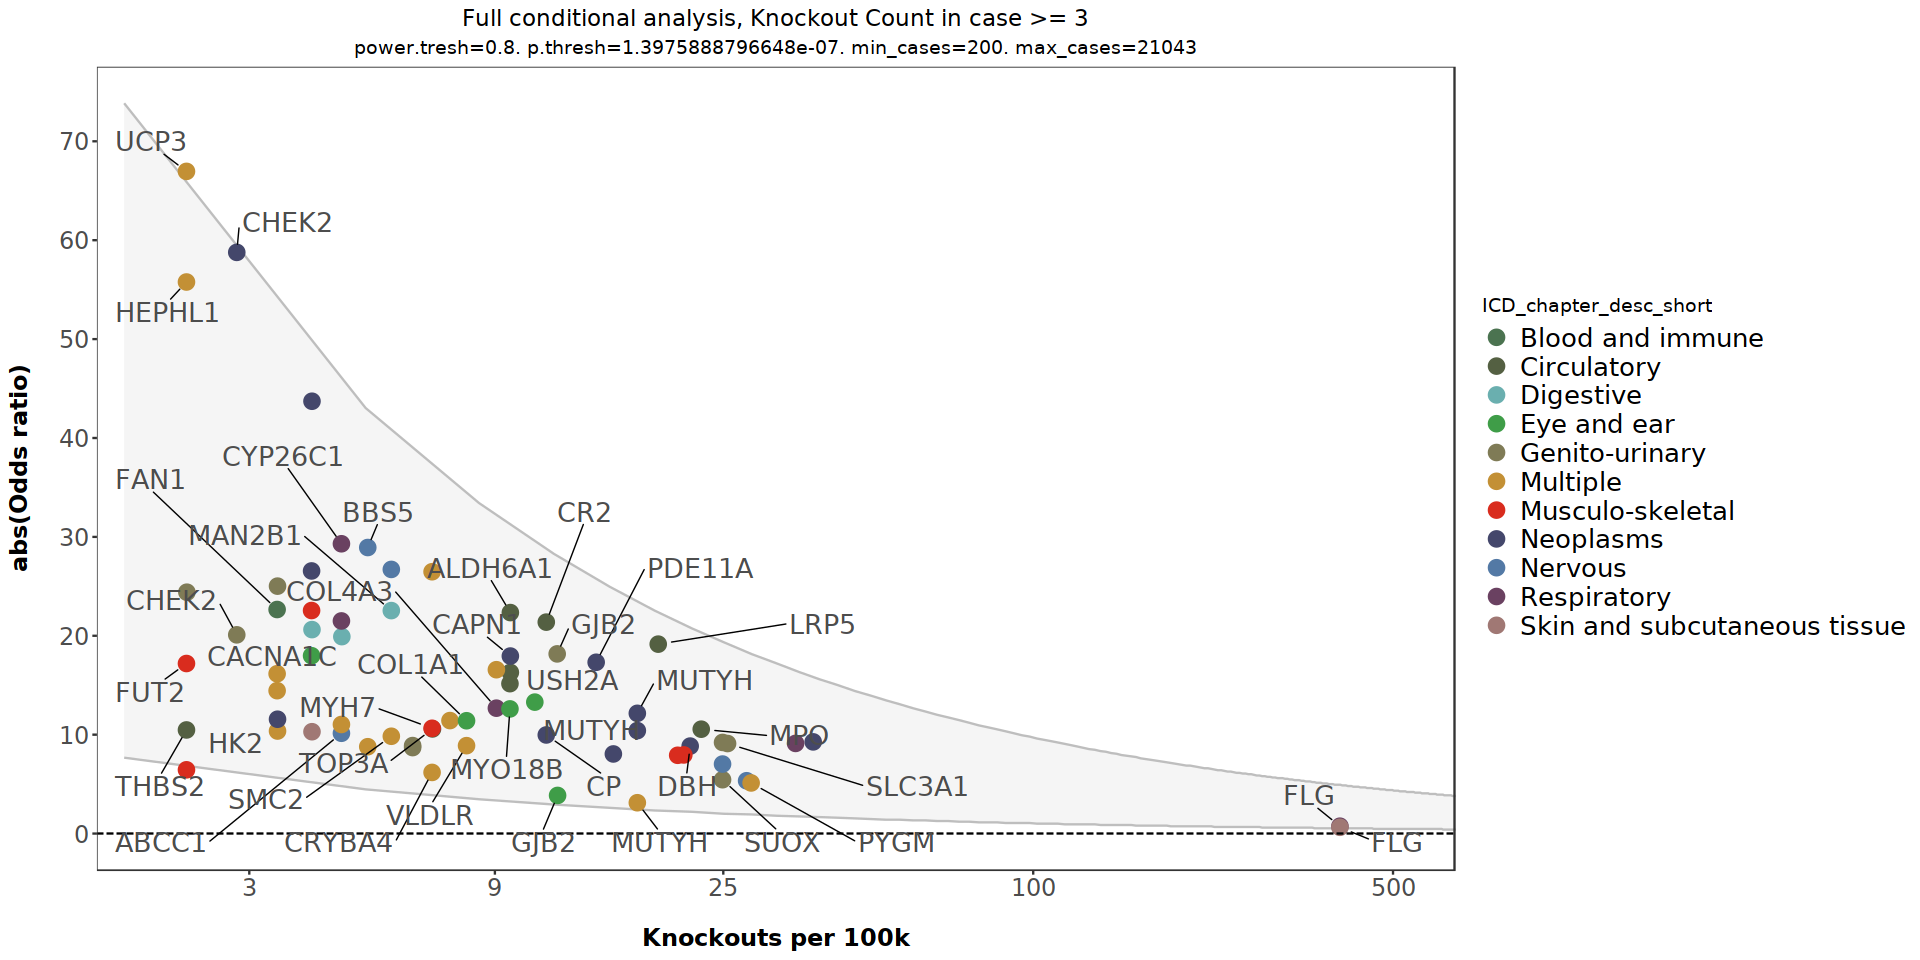

In [239]:
options(repr.plot.width=16, repr.plot.height=8)
#options(repr.plot.width=20, repr.plot.height=16)

# let's only plot OMIM genes
d_plot <- d
d_plot$hgnc_symbol[!d_plot$hgnc_symbol %in% genes_in_omim] <- NA


p <- ggplot() +
     geom_ribbon(
         data=mrg, 
         aes(x=log10(f), ymin=ymin, ymax=ymax), 
         alpha = 0.05,
         fill="grey30"
     ) +
     geom_point(#raster.dpi = 300,
         data = d_plot, 
                aes(
                    y=abs((BETA)),
                    ymax=abs((BETA+SE)),
                    ymin=abs((BETA-SE)),
                    x=log10(KF_ko),
                    label=hgnc_symbol, 
                    color=ICD_chapter_desc_short,
                ), size = 3.9, #alpha = 0.55,
                ) + 
    #geom_pointrange(size = 0.65) +
    #geom_point_rast(size = 3.5) +
    color_scale +
    #scale_alpha_discrete(range = c(0.3, 1, 1)) + 
    #scale_size_manual(values = c("2" = 2.5, "3-5"=4.5, "5+"=6)) +
    geom_hline(yintercept = 0, linetype = 'longdash') +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_x_continuous(breaks=log10(values), labels = labels) +
    coord_cartesian(xlim=log10(c(4/200000, 1000/200000))) +
    geom_text_repel(
        data = d_plot, aes(x=log10(KF_ko), y=abs(BETA), label=hgnc_symbol),
        box.padding = 0.75, point.padding = 0.95, #direction = "y" ,
        color = 'grey30', segment.color = 'black', max.overlaps=Inf, 
        size=5.5, segment.size=0.3, show.legend = FALSE, fontface = "italic"
    ) +
    xlab("Knockouts per 100k") +
    ylab("abs(Odds ratio)") +
    theme_bw() +
    theme(
        legend.position="right",
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.text=element_text(size=15),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) + ggtitle(title, subtitle) #+ facet_wrap(~ICD_chapter_desc_short)

p


[1] 71

In [242]:
d_plot[d_plot$phenotype %in% "spiro_dementia",]

phenotype,CHR,MarkerID,hgnc_symbol,MissingRate,BETA,SE,Tstat,var,p.value,⋯,N_ko,KF_ko,KF_case,KF_ctrl,prs,N_ko_case_bin,ICD_chapter,phenotype.y,ICD_chapter_desc,ICD_chapter_desc_short
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
spiro_dementia,chr11,ENSG00000181333,HEPHL1,0,55.7726,3.8267,3.80865,0.0682889,4.076005e-48,⋯,4,2.26517e-05,0.00225989,1.13829e-05,Without PRS,2,Multiple,Dementia,Multiple,Multiple


In [209]:
d_plot[d_plot$hgnc_symbol %in% "SUOX",]

phenotype,CHR,MarkerID,hgnc_symbol,MissingRate,BETA,SE,Tstat,var,p.value,⋯,N_ko,KF_ko,KF_case,KF_ctrl,prs,N_ko_case_bin,ICD_chapter,phenotype.y,ICD_chapter_desc,ICD_chapter_desc_short
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
spiro_glomerulonephritis,chr12,ENSG00000139531,SUOX,0,5.4449,1.02264,5.2065,0.956216,1.013037e-07,⋯,44,0.000249169,0.00326442,0.000233395,Without PRS,3-5,N,Glomerulonephritis,Genitourinary,Genito-urinary


In [110]:
outfile <- "derived/plots/230111_beta_vs_f.pdf"
ggsave(outfile, p,width = 17 , height = 8)

Warning message:
"Removed 33 rows containing missing values (`geom_text_repel()`)."


## Pleitropic effects of KOs

In [238]:
genes <- data.table(table(d$hgnc_symbol))
genes <- genes[genes$N > 1]
dt <- d[d$hgnc_symbol %in% genes$V1,]
dt <- data.table(table(dt$hgnc_symbol, dt$phenotype))
dt <- dt[dt$N > 0,]
dt <- dt[order(dt$V1),]
dt

V1,V2,N
<chr>,<chr>,<int>
CACNA1C,NAFLD_combined,1
CACNA1C,spiro_fatty_liver,1
CHEK2,spiro_acute_kidney_injury,1
CHEK2,spiro_leukaemia,1
FLG,spiro_asthma,1
FLG,spiro_dermatitis,1
GJB2,spiro_hearing_loss,1
GJB2,spiro_tubulo_interstitial_nephritis,1
MICAL2,spiro_crohns_disease,1


### Actual manhatten

In [14]:
header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
files <- list_files_saige(cond = "none", prs = "prefer")

n_tested_genes <- 1143
n_tested_phenos <- 313
significance_T <- 0.05 / (n_tested_genes * n_tested_phenos)

In [28]:
significance_T

[1] 1.397589e-07

In [135]:
d1 <- fread("data/post_hoc/results/165k_saige_cond_sig_subset_prefer_prs.txt.gz")
d1$phenotype <- gsub("chr[0-9]+\\_","",d1$phenotype)
d1 <- d1[d1$p.value < (0.05 / (313 * 1143)),]
d1 <- d1[d1$N_ko_case >= 2]
d1$hgnc_symbol[d1$hgnc_symbol == "n/a"] <- NA
d1$test_combo <- paste0(d1$hgnc_symbol,"_",d1$phenotype)

In [136]:
d2 <- fread("data/post_hoc/results/165k_saige_merge_prefer_prs.txt.gz")
d2 <- d2[d2$N_ko >= 4, ]
d2$hgnc_symbol[d2$hgnc_symbol == "n/a"] <- NA
d2$test_combo <- paste0(d2$hgnc_symbol,"_",d2$phenotype)
d2 <- d2[!d2$test_combo %in% unique(d1$test_combo),]

In [146]:
d <- rbind(d1, d2)
d$analysis <- factor(d$phenotype)
d$pvalue <- d$p.value

In [147]:
# get ICD and setup colors
library(paletteer)
icd <- fread("data/phenotypes/phenotype_icd_chapter.txt")
icd <- icd[order(icd$ICD_chapter),]
na_chapter <- "None of the above"
icd[is.na(icd$ICD_chapter_desc_short)]$ICD_chapter_desc_short <- na_chapter 
chapters <- unique(icd$ICD_chapter_desc_short)

# setup colors
my_colors <- c(colorRampPalette(paletteer_d("jcolors::pal8"))(length(chapters)), "grey")
names(my_colors) <- c(chapters, "na")
fill_scale <- scale_fill_manual(name = "ICD_chapter_desc_short", values = my_colors)
color_scale <- scale_color_manual(name = "ICD_chapter_desc_short", values = my_colors)

In [148]:
# combine data with ICD mapping
d <- merge(icd, d, by.x = "unix_code", by.y = "analysis", all.x = TRUE)
d$analysis <- d$unix_code
d$ICD_chapter_desc[is.na(d$ICD_chapter_desc)] <- na_chapter
d$ICD_chapter_desc_short[is.na(d$ICD_chapter_desc_short)] <- na_chapter

In [149]:
# helper for getting gene start/end
get_start_and_end <- function(chr_lengths) {
    start <- rep(0, length(chr_lengths))
    start[1] <- 1
    end <- rep(0, length(chr_lengths))
    end[1] <- chr_lengths[1]
    for(chr in 2:length(chr_lengths)) {
        start[chr] <- start[chr-1] + chr_lengths[chr-1]
        end[chr] <- end[chr-1] + chr_lengths[chr]
    }
    return(list(start=start, end=end))
}

# lengths for chromosome
chr_lengths_38 <- c(248956422, 242193529, 198295559,190214555,181538259,170805979,159345973,
    145138636,138394717,133797422,135086622,133275309,114364328,107043718,101991189,90338345,
    83257441,80373285,58617616,64444167,46709983,50818468,156040895)
contigs_ <- c(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)

# thresholds for plotting
buffer <- 100000000


n_tested_genes <- 1143
n_tested_phenos <- 313
significance_T <- 0.05 / (n_tested_genes * n_tested_phenos)

In [150]:
# get hits that pass our sig thresholds
sig_table <- as.data.frame(table(d$pvalue < significance_T, d$analysis))
sig_table <- sig_table[sig_table$Var1 == TRUE, ]
sig_table <- sig_table[,c(2,3)]
colnames(sig_table) <- c("phenotype", "hits")

# summarize hits in vector
sig_phenos <- as.character(unique(sig_table$phenotype[sig_table$hits > 0]))
not_sig_phenos <- as.character(unique(sig_table$phenotype[sig_table$hits == 0]))
n_sig <- length(sig_phenos)

In [151]:
# only plot things that are exome wide significnat
dt <- d
dt <- dt[dt$analysis %in% sig_phenos,]
#dt <- dt[dt$AC_Allele2 >= 8, ]
#dt <- dt[dt$N_case_hom >= 2, ]

dt$significant <- dt$pvalue < significance_T
dt$label <- dt$hgnc_symbol 
dt$label[dt$pvalue > significance_T] <- NA
#dt$label[!dt$hgnc_symbol %in% genes_in_omim] <- NA

dt$ICD_chapter_desc_short_sig <- dt$ICD_chapter_desc_short
dt$ICD_chapter_desc_short_sig[dt$pvalue > significance_T] <- "na"

In [152]:
contigs <- dt #dt$contig
positions <- dt$pos
pvals <- dt$pvalue
labels <- dt$label
significant <- dt$significant
phenotypes <- dt$analysis
n_ko_case <- dt$N_ko_case
ICD_chapter <- dt$ICD_chapter
ICD_chapter_desc_short <- factor(dt$ICD_chapter_desc_short, levels=unique(icd$ICD_chapter_desc_short))
ICD_chapter_desc_short_sig <- factor(dt$ICD_chapter_desc_short_sig)
c(contigs[1],positions[1],pvals[1],labels[1],phenotypes[1], n_ko_case[1], ICD_chapter_desc_short_sig[1])

[1] "2.864882e-47" "MUTYH"        "CC_combined"  "10"           "11"

In [155]:
# get contigs
start_end <- get_start_and_end(chr_lengths_38)
dt_contigs <- data.frame(contig=contigs_, start=start_end$start, end=start_end$end) %>%
mutate(middle = floor(start + (end-start)/2),
       length = (end-start)) %>%
mutate(shifted_position=middle + (contig - 1) * buffer)

In [156]:
c(
    length(contigs),
    length(positions),
    length(pvals),
    length(labels),
    length(significant),
    length(phenotypes),
    length(n_ko_case),
    length(ICD_chapter),
    length(ICD_chapter_desc_short)
)

[1]     0     0 12781 12781 12781 12781 12781 12781 12781

In [25]:
# setup plotting
dt_plot <- data.frame(
    contig=contigs, 
    position=as.integer(positions), 
    pval=as.numeric(pvals), 
    labels=labels,
    significant=significant,
    phenotype=phenotypes,
    ICD_chapter=ICD_chapter,
    ICD_chapter_desc_short=ICD_chapter_desc_short,
    ICD_chapter_desc_short_sig=ICD_chapter_desc_short_sig
) %>% mutate(
        x = dt_contigs[gsub('X', '23', contig), 'start'] + position + (as.integer(gsub('X', '23', contig))-1)*buffer,
        y = pvals
)

In [26]:
length(unique(dt$hgnc_symbol[dt$significant]))
length(unique(dt$analysis[dt$significant]))

[1] 112

[1] 72

Warning message:
"Removed 10 rows containing missing values (`geom_point()`)."
Warning message:
"Removed 6928 rows containing missing values (`geom_text_repel()`)."
Warning message:
"ggrepel: 121 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


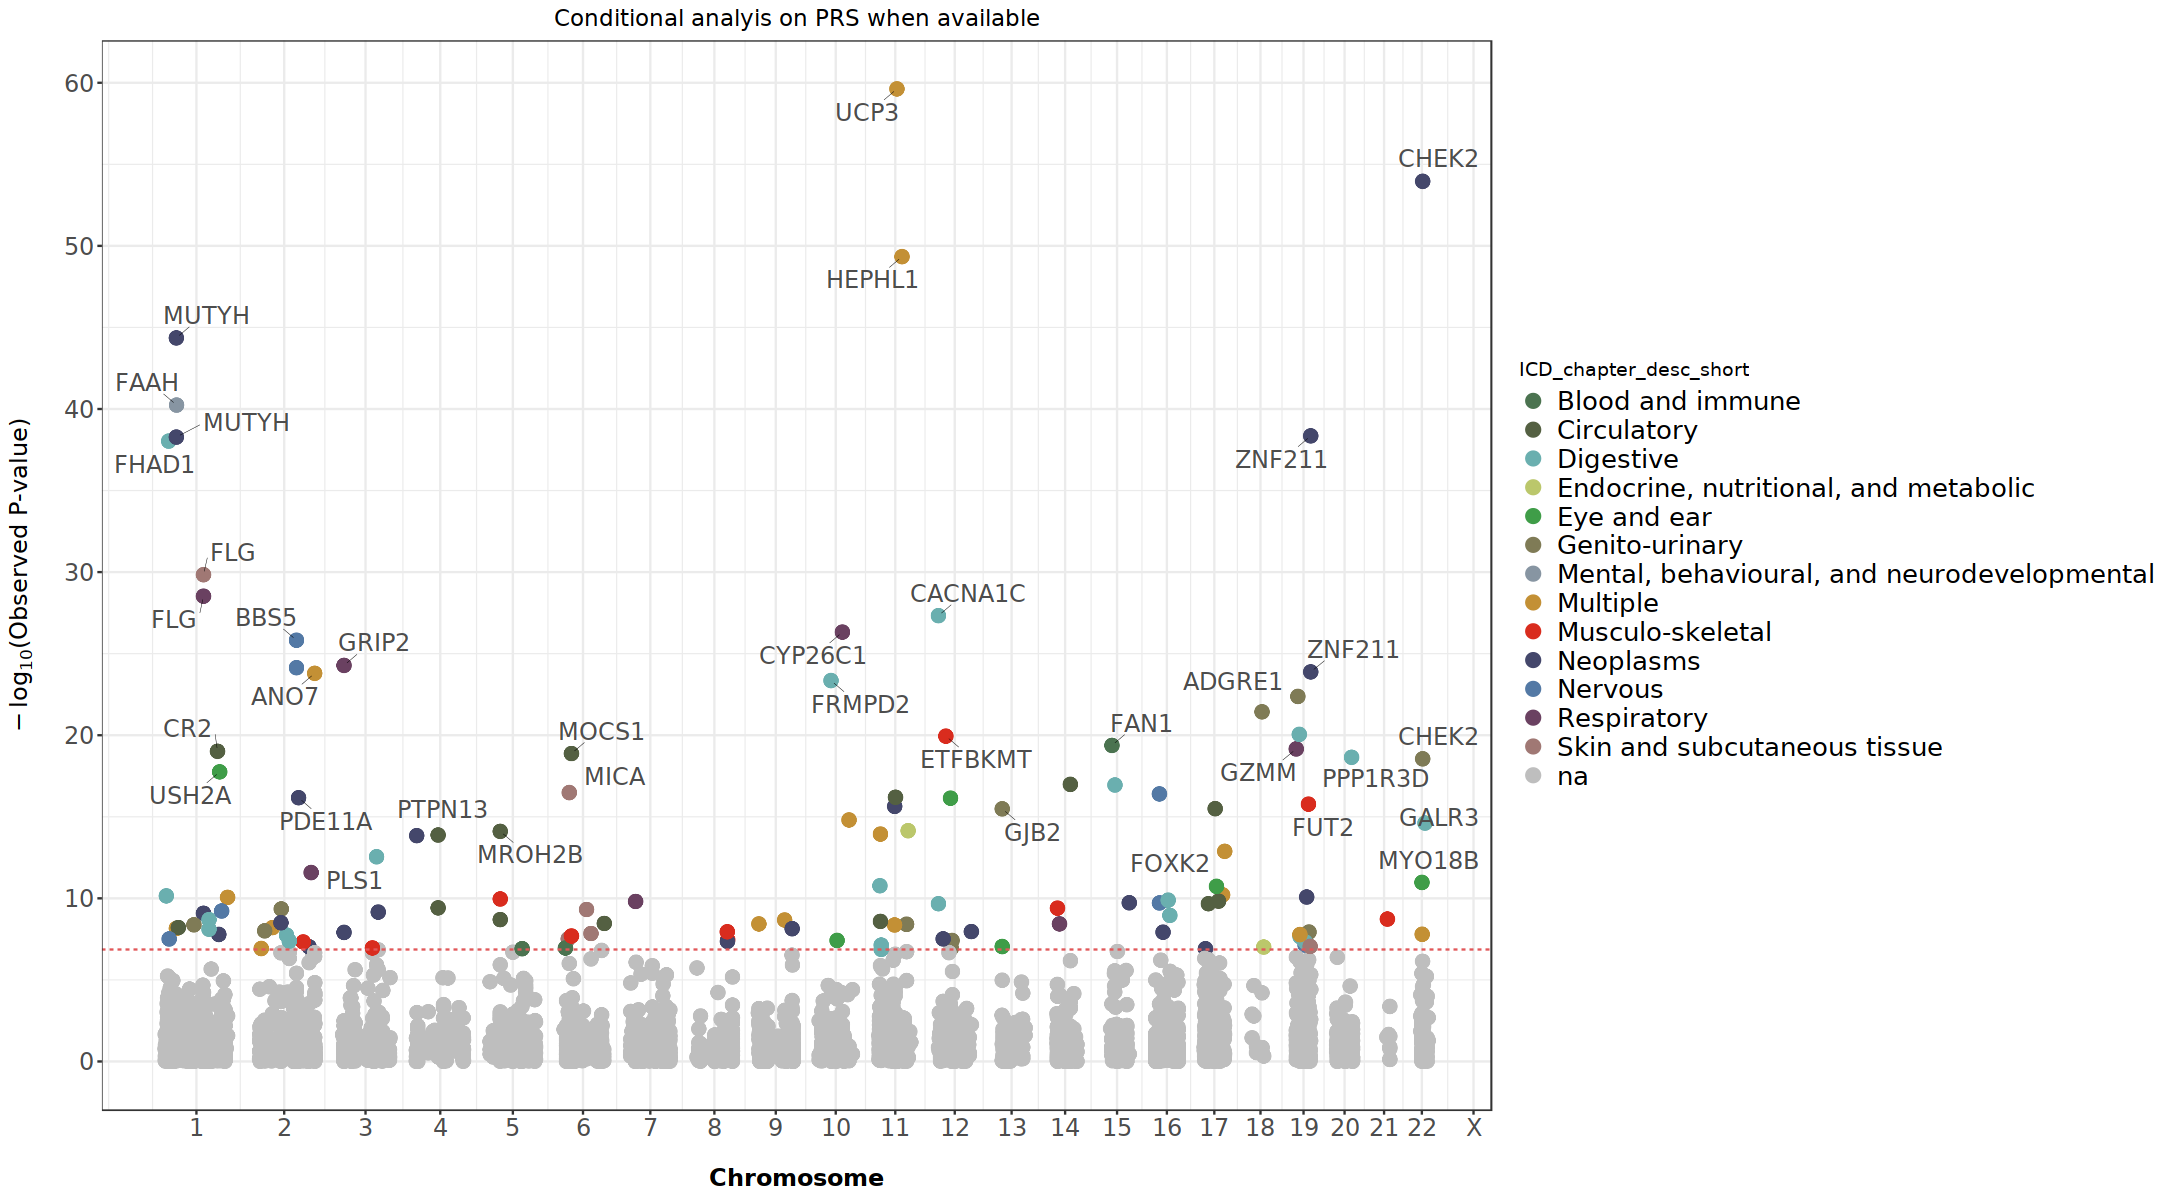

In [27]:
options(repr.plot.width=18, repr.plot.height=10)
p <- ggplot(dt_plot, aes(x=x,y=-log10(y),label=labels, color=ICD_chapter_desc_short_sig)) + 
    geom_point_rast(size = 3.5) +
    color_scale +
    #scale_alpha_discrete(range = c(0.8, 1)) +
    geom_hline(yintercept=-log10(significance_T), color='#E15759', linetype='dashed') +
    scale_x_continuous(breaks=dt_contigs$shifted_position, labels=gsub(23, 'X', dt_contigs$contig)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=8)) +

    geom_text_repel(
        box.padding = 0.5, point.padding = 0.2,
        color = 'grey30', segment.color = 'black', max.overlaps=5,
        size=5, segment.size=0.1, show.legend = FALSE, fontface = "italic"
    ) +
    xlab("Chromosome") +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    theme_bw() +
    theme(
        legend.position="right",
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.text=element_text(size=15)
    ) +
    #facet_wrap(~facets) +
    ggtitle(paste0("Conditional analyis on PRS when available"))

p

In [489]:
outfile <- "derived/plots/230107_manhatten_cond_prs_omim_labels.pdf"
ggsave(outfile, p, width = 22, height = 8, dpi = 300)

Warning message:
"Removed 10 rows containing missing values (geom_point)."
Warning message:
"Removed 6998 rows containing missing values (geom_text_repel)."
Warning message:
"ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


### QQ-plotting

In [23]:
header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
files <- list_files_saige(cond = "none", prs = "include")

# filter files by the ones in header
regex <- paste0("200k_", header, "_pLoF_")
files <- unlist(lapply(regex, function(re) files[grepl(re, files)]))

n_tested_genes <- 1143
n_tested_phenos <- 313
significance_T <- 0.05 / (n_tested_genes * n_tested_phenos)

In [24]:
#options(repr.matrix.max.cols=50, repr.matrix.max.rows=20)
#qq <- get_qq_df(files[1])
#d <- fread(files[1])
#gene <- "ENSG00000148483"
#d[d$MarkerID %in% gene, ]
#qq[qq$ensembl_gene_id %in% gene, ]

In [5]:
pattern <- "ukb_eur_wes_200k.+.\\.txt.gz"
files <- list.files("data/saige/output/binary/step2/min_mac4/", pattern = pattern, full.names = TRUE)

In [25]:
# get phenotypes and diagnosis
lst_ds <- lapply(files, function(f){
    write(f, stderr())
    diagnosis <- stringr::str_extract(basename(f), "200k_([A-Z]|[a-z]|[0-9]|\\_)+_pLoF")
    diagnosis <- gsub("(200k_)|(_pLoF)","", diagnosis)
    d <- get_qq_df(f, AC_Allele2_cutoff = 4)
    if (!is.null(d)) {
        d$phenotype <- diagnosis
        return(d)   
    } else {
        return(NULL)
    }
})

# omit any nulls (because of invalid P-values)
lst_ds <- lst_ds[!sapply(lst_ds,is.null)]
ds <- do.call(rbind, lst_ds)



In [26]:
head(ds)

ensembl_gene_id,AC_Allele2,N_case_hom,pvalue,pvalue.observed,pvalue.expected,clower,cupper,prs,analysis,hgnc_symbol,contig,pos,label,phenotype
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
ENSG00000008710,6,2,0.0009284467,3.032243,3.278525,4.874873,2.711824,FALSE,NA,PKD1,16,2112303,NA,BC_combined
ENSG00000147324,6,2,0.0009790513,3.009195,2.977495,3.894019,2.532836,FALSE,NA,MFHAS1,8,8838492,NA,BC_combined
ENSG00000100412,18,2,0.0018410550,2.734933,2.801404,3.486678,2.420075,FALSE,NA,ACO2,22,41488552,NA,BC_combined
ENSG00000164961,8,2,0.0044769460,2.349018,2.676465,3.240705,2.336092,FALSE,NA,WASHC5,8,125058040,NA,BC_combined
ENSG00000183765,10,2,0.0054300230,2.265198,2.579555,3.067575,2.268643,FALSE,NA,CHEK2,22,28715082,NA,BC_combined
ENSG00000104043,16,3,0.0056444670,2.248377,2.500374,2.935179,2.212051,FALSE,NA,ATP8B4,15,50020528,NA,BC_combined


In [51]:
# Let's get inflations tats
inflation_lst <- lapply(lst_ds, function(x){
    inflation_all <- calc_inflation(x$pvalue)
    inflation_ko2 <- calc_inflation(x$pvalue[(x$AC_Allele2 >= 0) & (x$AC_Allele2 < 10)])
    inflation_ko3 <- calc_inflation(x$pvalue[(x$AC_Allele2 >= 10) & (x$AC_Allele2 < 30)])
    inflation_ko5 <- calc_inflation(x$pvalue[(x$AC_Allele2 >= 3) & (x$AC_Allele2 < 100)])
    #inflation_ko2 <- calc_inflation(x$pvalue[(x$N_case_hom > 0) & (x$N_case_hom <= 2)])
    #inflation_ko3 <- calc_inflation(x$pvalue[(x$N_case_hom > 0) & (x$N_case_hom <= 3)])
    #inflation_ko5 <- calc_inflation(x$pvalue[(x$N_case_hom > 0) & (x$N_case_hom <= 5)])
    phenotype <- unique(x$phenotype)
    prs <- unique(x$prs)
    return(data.table(phenotype, prs, inflation_all, inflation_ko2, inflation_ko3, inflation_ko5))    
})

# combine 
d_inflation <- do.call(rbind, inflation_lst)

In [52]:
traits_with_prs <- d_inflation$phenotype[d_inflation$prs]

In [53]:
d_inflation_with_prs <- d_inflation[d_inflation$phenotype %in% traits_with_prs, ]
d_inflation_with_prs <-  melt(d_inflation_with_prs)

Using phenotype, prs as id variables



In [54]:
# setup color scale
my_colors <- c("#CC6666","#65B8EF") #c("#7BA98A","#65B8EF")
names(my_colors) <- c("FALSE", "TRUE")
fill_scale <- scale_fill_manual(name = "prs", values = my_colors)
color_scale <- scale_color_manual(name = "prs", values = my_colors)

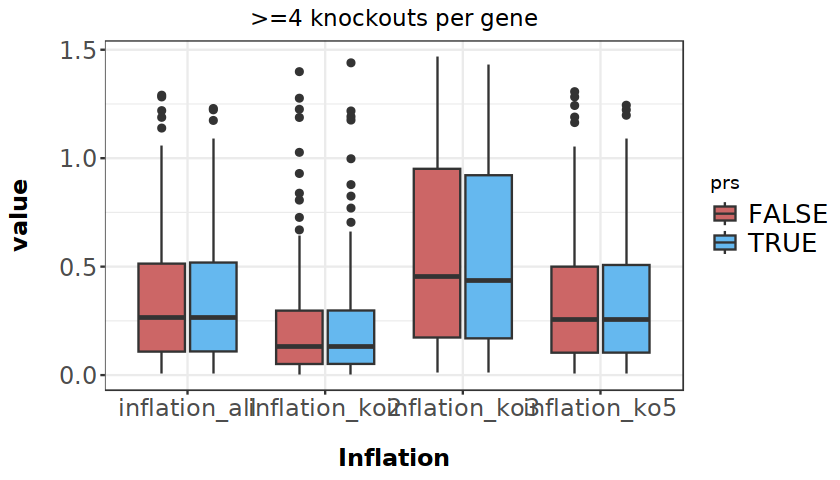

In [55]:
options(repr.plot.width=7, repr.plot.height=4)
ggplot(d_inflation_with_prs, aes(x=variable, y=value, fill=prs)) +
    geom_boxplot() + 
    fill_scale +
    #scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab("Inflation") +
    theme_bw() +
    theme(
        legend.position="right",
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.text=element_text(size=15)
    ) +
    ggtitle(">=4 knockouts per gene")


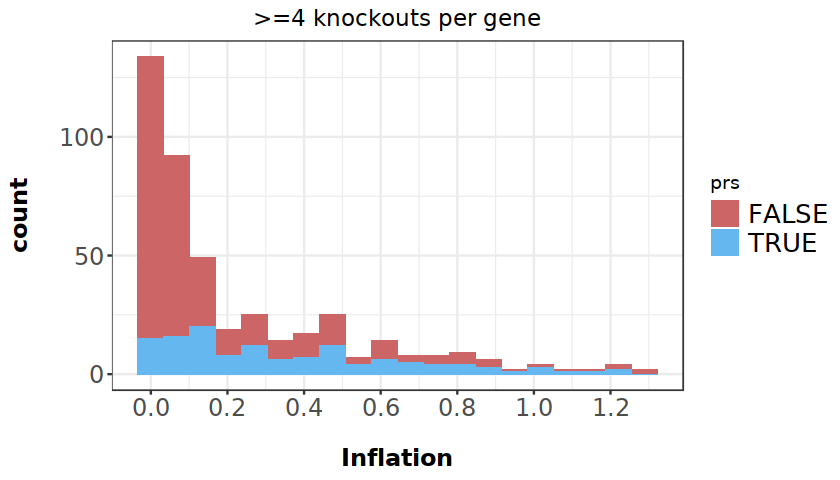

In [18]:
options(repr.plot.width=7, repr.plot.height=4)
ggplot(d_inflation_with_prs, aes(x=inflation, fill=prs)) +
    geom_histogram(bins = 20) + 
    fill_scale +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab("Inflation") +
    theme_bw() +
    theme(
        legend.position="right",
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.text=element_text(size=15)
    ) +
    ggtitle(">=4 knockouts per gene")


In [5]:
#files <- list_files_saige(cond = "none", prs = "include", use_old = FALSE)
#head(files)

In [6]:
# read the header and subset files ---- 
header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
files <- list_files_saige(cond = "none", prs = "include", use_old = FALSE)
regex <- paste0("200k_", header, "_pLoF_")
files <- unlist(lapply(regex, function(re) files[grepl(re, files)]))

#head(files)

# extract the files ----
lst_ds <- lapply(files, function(f){
    write(f, stderr())
    diagnosis <- stringr::str_extract(basename(f), "200k_([A-Z]|[a-z]|[0-9]|\\_)+_pLoF")
    diagnosis <- gsub("(200k_)|(_pLoF)","", diagnosis)
    d <- get_qq_df(f, AC_Allele2_cutoff = 8)
    if (!is.null(d)) {
        d$phenotype <- diagnosis
        return(d)   
    } else {
        return(NULL)
    }
})

# omit any nulls (because of invalid P-values)
lst_ds <- lst_ds[!sapply(lst_ds,is.null)]
ds <- do.call(rbind, lst_ds)

In [7]:
#head(ds[(ds$phenotype == "LC_combined") & (ds$prs == TRUE),])
#head(ds[(ds$phenotype == "LC_combined") & (ds$prs == FALSE),])

In [8]:
#load("data/saige/output/binary/step1/ukb_wes_200k_LC_combined.rda")
#load("data/saige/output/binary/old_old/step1/chroms/ukb_wes_200k_CC_combined_chr1.rda")
#length(modglmm$sampleID)

In [23]:
nrow = 3 
ncol = 3
n_pages <- ceiling(length(unique(ds$phenotype))/ (nrow*ncol))

In [193]:
which(unique(ds$phenotype) == "PSOR_combined")

[1] 22

In [22]:
for (page in 1:10){
    
    write(paste("writing page", page), stderr())
    
    p <- ggplot(ds, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, label = label, color=prs)) +
        geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
        geom_point_rast(size = 1.5) +
        geom_abline(linetype = 'dotted') + 
        scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
        scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
        xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
        ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
        color_scale +
        facet_wrap_paginate(~phenotype, nrow = nrow, ncol = ncol, page = page, scales = "free") +
        theme_bw() 
    
    outdir <- "derived/plots/qq/"
    outfile <- paste0(outdir, "free_165k_qqplot_",page,"of",n_pages,".pdf")
    ggsave(outfile, p, width = 9, height = 7)
    
    
}

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(ds, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, label = label, color=prs)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point_rast(size = 2, dpi=200) +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    color_scale +
    facet_wrap_paginate(~phenotype, nrow = 3, ncol = 3, page = 1, scales = "free_y") +
    theme_bw() 


In [8]:
d <- fread("data/prs/scores_full/DEM_combined_pgs_chrom.txt.gz")

[1] FALSE

In [6]:
old_dem <- fread("data/prs/scores/DEM_combined_pgs_chrom.txt.gz")
new_dem <- fread("data/prs/scores_potential_zero_error/DEM_combined_pgs_chrom.txt.gz")

In [20]:
files <- list.files("data/prs/scores_potential_zero_error/", pattern = "chrom.txt.gz", full.names = TRUE)

In [22]:
test <- lapply(files, function(f){
    
    sigma <- sum(colSums(head(new_dem)[,grepl("chr",colnames(new_dem)),with=FALSE] == 0) != 0)
    data.frame(f, sigma)
})


In [23]:
do.call(rbind, test)

f,sigma
<chr>,<int>
data/prs/scores_potential_zero_error//AD_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//BC_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//CC_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//CD_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//CIRR_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//CLD_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//COPD_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//DEM_combined_pgs_chrom.txt.gz,5
data/prs/scores_potential_zero_error//DEP_combined_pgs_chrom.txt.gz,5


In [3]:
fread("data/prs/scores_new/LC_combined_pgs_chrom.txt.gz", nrows = 10)

sid,chr1,chr2,chr3,chr4,chr5,chr6,chr7,chr8,chr9,⋯,chr13,chr14,chr15,chr16,chr17,chr18,chr19,chr20,chr21,chr22
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,⋯,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
1000028,0.1386771526,-0.022923881,-0.018828343,-0.01332872,0.144705527,0.009790081,0,-0.10067527,0,⋯,-0.064778045,0,-0.13417288,0.060172269,-0.039885479,0,0,-0.21804826,0.0424748990,0.056523574
1000034,0.1135332026,-0.038942430,0.007535355,0.10827261,0.004548671,0.141305734,0,0.23409686,0,⋯,0.023432130,0,-0.09434968,-0.069581073,0.032814364,0,0,0.06483027,0.0507330196,0.008136731
1000087,0.0008562188,-0.020975480,0.022345297,0.10487628,0.027556222,-0.078132930,0,-0.29133540,0,⋯,0.166076350,0,0.33440993,0.050174290,-0.062810131,0,0,0.11174250,0.0052897005,0.031140394
1000118,-0.0351691000,0.059375712,-0.121765252,0.21582124,-0.083777013,-0.073465366,0,0.22609176,0,⋯,-0.009384038,0,-0.05978483,0.024010403,0.022290120,0,0,-0.05104630,-0.0001823289,-0.087471787
1000120,0.1402135977,-0.090682844,-0.012434265,0.06346303,-0.016590612,-0.016093863,0,0.08219138,0,⋯,0.085376754,0,-0.08713684,-0.022213717,-0.002905808,0,0,-0.06395950,0.0682273655,0.024077104
1000162,0.0147741647,-0.194593820,-0.076697838,0.00976527,-0.026164290,-0.056840174,0,0.21630428,0,⋯,-0.031973539,0,0.02433777,-0.101399586,-0.139671734,0,0,0.12212189,-0.0254815353,-0.021627937
1000171,0.0247308093,0.222942120,0.014932928,-0.01112763,0.102711502,0.015521002,0,0.05026772,0,⋯,-0.101235103,0,-0.19435031,0.071779407,0.080163872,0,0,-0.05713462,0.1032202790,-0.007394309
1000196,-0.0227534684,0.090298378,0.163125019,-0.03437137,0.023046261,-0.037634922,0,0.24428693,0,⋯,0.044784963,0,-0.15469968,0.064520033,-0.099864103,0,0,0.08640519,-0.0705487540,0.032459289
1000254,-0.0214290294,-0.004256495,0.067453560,-0.18393770,-0.092473243,-0.071193500,0,0.16700047,0,⋯,0.031614047,0,-0.16315291,-0.003258173,-0.002987021,0,0,0.24061974,0.0134845000,-0.040683481


In [ ]:
#colSums(fread("data/prs/scores_new/CIRR_combined_pgs_chrom.txt.gz", nrows = 10))

In [ ]:
ds[ds$phenotype == "DM_t2D"]

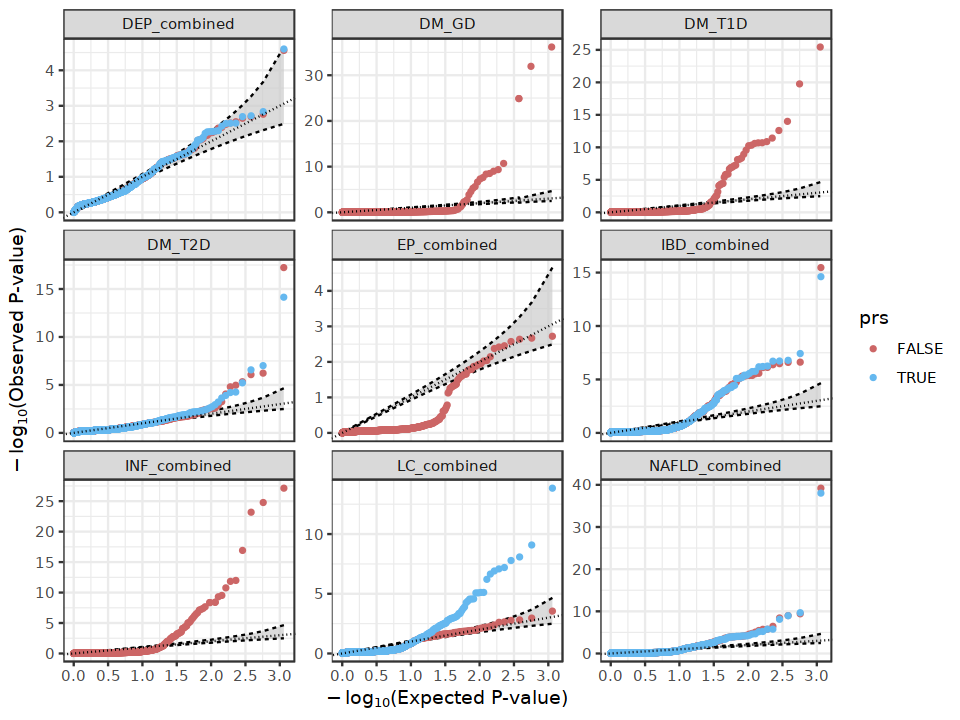

In [205]:
options(repr.plot.width=8, repr.plot.height=6)
ggplot(ds, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, label = label, color=prs)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point(size = 1) +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    color_scale +
    #geom_label_repel(
    #    box.padding = 0.4, label.padding=0.1, point.padding = 0.2,
    #    color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
    #    size=2, segment.size=0.1, show.legend = FALSE
    #) +
    facet_wrap_paginate(~phenotype, nrow = 3, ncol = 3, page = 2, scales = "free_y") +
    theme_bw() 
    #theme(
    #    strip.text = element_text(size=10),
    #    axis.text=element_text(size=10),
    #    axis.title=element_text(size=10,face="bold"),
    #    axis.title.x = element_text(margin=ggplot2::margin(t=16)),
    #    axis.title.y = element_text(margin=ggplot2::margin(r=16)),
    #    plot.title = element_text(hjust=0.5),
    #    plot.subtitle = element_text(hjust=0.5),
    #    legend.position="top"
    #)

## Post hoc analysis on variants

In [14]:
d <- fread("data/prs/validation/230118_chrom/BC_combined_pgs_chrom.txt.gz")

In [15]:
d

V1,V2,filepath
<chr>,<chr>,<chr>
chr1,chr1,BC_combined_pgs_chrom.txt.gz
chr1,chr2,BC_combined_pgs_chrom.txt.gz
chr1,chr3,BC_combined_pgs_chrom.txt.gz
chr1,chr4,BC_combined_pgs_chrom.txt.gz
chr1,chr5,BC_combined_pgs_chrom.txt.gz
chr1,chr6,BC_combined_pgs_chrom.txt.gz
chr1,chr7,BC_combined_pgs_chrom.txt.gz
chr1,chr8,BC_combined_pgs_chrom.txt.gz
chr1,chr9,BC_combined_pgs_chrom.txt.gz


### Functions for obtaining category count among phenotypes

In [3]:


# extract column categories by their sums
extract_category_sums <- function(d){
    cols_to_keep <- c("is_chet","is_cis","is_hom")
    stopifnot(all(cols_to_keep %in% colnames(d)))
    counts <- data.frame(t(matrix(colSums(d[,cols_to_keep, with=FALSE]))))
    colnames(counts) <- cols_to_keep
    return(counts)

}

# extract counts of KO/CIS/CHET for samples that are cases
extract_knockout_counts <- function(phenotype, gene, samples, phenotypes){
    stopifnot(gene %in% samples$ensembl_gene_id)
    stopifnot(phenotype %in% colnames(phenotypes))
    stopifnot("eid" %in% colnames(phenotypes))
    eids <- phenotypes$eid[phenotypes[[phenotype]]]
    samples_genes <- samples[samples$ensembl_gene_id %in% gene,]
    affected_all <- extract_category_sums(samples_genes)
    samples_genes_cases <- samples_genes[samples_genes$s %in% eids, ]
    affected_cases <- extract_category_sums(samples_genes_cases)
    affected_all$affected <- "all"
    affected_cases$affected <- "cases"
    combined <- rbind(affected_all, affected_cases)
    combined$gene <- gene
    combined$phenotype <- phenotype
    return(combined)
}


### Cox-proportional hazards

In [194]:
library(tidyverse)
library(RColorBrewer)
library(ggpubr)
library(ggrepel)
theme_set(theme_bw())

In [195]:
# Read results tables ----
uncond <- read.table("/well/lindgren-ukbb/projects/ukbb-11867/samvida/for_fred_ko_project/2212_analyses/results/all_coxph_results.txt",
                  sep = "\t", header = T, stringsAsFactors = F, quote = "", 
                  comment.char = "$")
uncond <- uncond %>% 
  mutate(test_combo = paste0(gene, ":", diagnosis),
         analysis_type = "unconditioned")

cond <- read.table("/well/lindgren-ukbb/projects/ukbb-11867/samvida/for_fred_ko_project/2212_analyses/prs_conditioned_results/all_coxph_results.txt",
                     sep = "\t", header = T, stringsAsFactors = F, quote = "", 
                     comment.char = "$")
cond <- cond %>% 
  mutate(test_combo = paste0(gene, ":", diagnosis),
         analysis_type = "conditioned")


In [196]:
#fwrite(cond, "derived/tables/prs_cond_surv.txt.gz")
#fwrite(uncond, "derived/tables/prs_uncond_surv.txt.gz")

In [197]:
# Combine results
dat <- bind_rows(uncond, cond)
dat <- dat %>% 
  pivot_wider(values_from = c(estimate, std.error, p.value),
              names_from = analysis_type)

source("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/scripts/post_hoc/utils.R")
mapping <- get_mapping_ensembl_to_hgnc()
dat$hgnc_symbol <- mapping[dat$gene]

# Set multiple-testing thresholds 
unique_comb_tests <- unique(uncond$test_combo)
PTHRESH <- 0.05/length(unique_comb_tests)

# Forest plot for hazard ratios ----

dat$min_p <- pmin(dat$p.value_unconditioned, dat$p.value_conditioned)
combos_plot <- dat$test_combo[which(dat$term == "knockout" & dat$min_p <= PTHRESH)]

# order test-combos by estimate size for knockouts
for_ordering <- dat %>% 
  filter(test_combo %in% combos_plot & term == "knockout") 

for_ordering$est_plot <- pmax(for_ordering$estimate_unconditioned, 
                              for_ordering$estimate_conditioned)
for_ordering <- for_ordering %>%
  arrange(est_plot, desc = T) %>%
  mutate(print_combo = paste0(hgnc_symbol, ":", diagnosis))

# Only plot knockout HRs
forest_dat <- bind_rows(uncond, cond) 
forest_dat$hgnc_symbol <- mapping[forest_dat$gene]
forest_dat <- forest_dat %>%
  filter(test_combo %in% combos_plot & term %in% c("chet_cis","wt","knockout")) %>%
  mutate(lci = estimate - 1.96*std.error,
         uci = estimate + 1.96*std.error,
         analysis_type = factor(analysis_type, levels = c("conditioned", "unconditioned")),
         plabel = paste0("P = ", gsub("e", "E", signif(p.value, digits = 3))),
         print_combo = factor(paste0(hgnc_symbol, ":", diagnosis), 
                              levels = for_ordering$print_combo))
# only display conditional P-value
forest_dat$plabel[forest_dat$analysis_type == "unconditioned"] <- NA

Warning message:
"Removed 12 rows containing missing values (`geom_pointrange()`)."
Warning message:
"Removed 6 rows containing missing values (`geom_segment()`)."
Warning message:
"Removed 17 rows containing missing values (`geom_text_repel()`)."


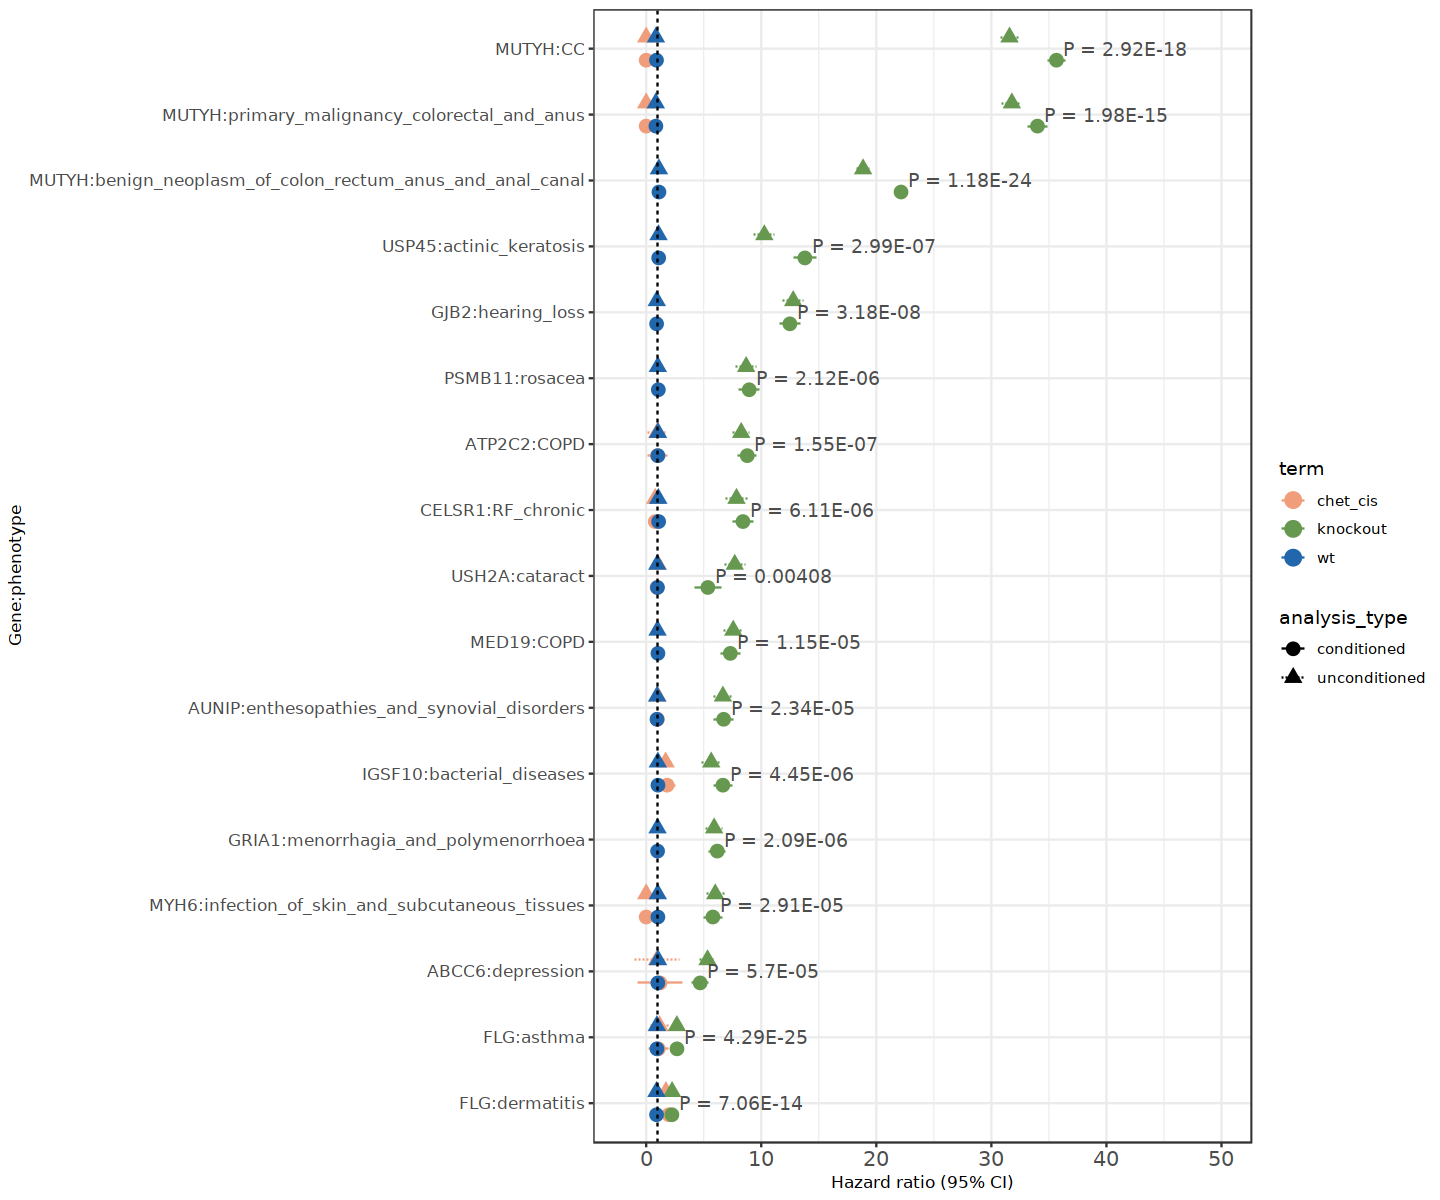

In [198]:
options(repr.plot.width=12, repr.plot.height=10)
custom_col_pal <- c("#B13F64", # dark red - hets
                    "#F09D7C", # orange - chet-cis
                    "#669850", # green - knockouts
                    "#2266AC") # blue - wildtype
custom_col_pal <- setNames(custom_col_pal, c("het", "chet_cis", "knockout", "wt"))

pd <- position_dodge(width = 0.7)
res_plot <- ggplot(forest_dat, aes(x = estimate, y = print_combo,
                                   group = analysis_type, label=plabel)) +
  geom_pointrange(aes(xmin = lci, xmax = uci,
                      shape = analysis_type, color = term,
                      linetype = analysis_type, size = 3.5),
                  position = pd,
                  size = 0.8) +
  geom_text_repel(data = subset(forest_dat, forest_dat$term == "knockout"),
                  size = 4, direction = "x", nudge_x=5, color = 'grey30') +
  geom_vline(xintercept = 1, linetype = 2) +
  scale_color_manual(values = custom_col_pal) +
  scale_x_continuous(limits = c(-2, 50), guide = guide_axis(check.overlap = TRUE)) +
  labs(x = "Hazard ratio (95% CI)", y = "Gene:phenotype") +
  theme(axis.title = element_text(size = 10),
        axis.text.x = element_text(size = 12),
        axis.text.y = element_text(size = 10))

res_plot
#outfile <- paste0("derived/plots/220108_hazard_model_cond_uncond.pdf")
#ggsave(outfile, res_plot, width = 12, height = 10, dpi = 300)


In [54]:
d <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEx.tstat.tsv")
d <- cbind(gene_id = d$ENSGID, data.table(apply(d[,-1], 2, function(x) x > quantile(x, probs = 0.90))))
colnames(d) <- gsub("\\_$","",gsub("\\_+","\\_",gsub("(\\()|(\\)|(\\-))","_",colnames(d))))                               

In [ ]:
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id

In [55]:
cols <- colnames(d)
tissue_specific_dt <- do.call(rbind, lapply(1:nrow(d), function(idx){
    gene <- d$gene_id[idx]
    row <- unlist(d[idx, 2:ncol(d)])
    tissue_specific <- names(row[row])
    out <- data.table(gene_id=gene, tissues=paste0(tissue_specific, collapse = ";"))
    return(out)
}))

In [63]:
tissue_specific_dt <- tissue_specific_dt[tissue_specific_dt$tissue != "",]
tissue_specific_dt$hgnc_symbol <- ensembl_to_hgnc[tissue_specific_dt$gene_id]
tissue_specific_dt <- tissue_specific_dt[,c("gene_id","hgnc_symbol","tissues")]
tissue_specific_dt

gene_id,hgnc_symbol,tissues
<chr>,<chr>,<chr>
ENSG00000000419,DPM1,Adrenal_Gland;Cells_EBV_transformed_lymphocytes;Cells_Transformed_fibroblasts;Heart_Left_Ventricle
ENSG00000000457,SCYL3,Bladder;Breast_Mammary_Tissue;Cervix_Ectocervix;Cervix_Endocervix;Colon_Transverse;Minor_Salivary_Gland;Nerve_Tibial;Prostate;Skin_Sun_Exposed_Lower_leg;Stomach;Thyroid
ENSG00000000460,C1orf112,Cells_EBV_transformed_lymphocytes;Nerve_Tibial
ENSG00000000938,FGR,Cells_EBV_transformed_lymphocytes;Lung;Spleen;Whole_Blood
ENSG00000000971,CFH,Adipose_Subcutaneous;Artery_Aorta;Artery_Coronary;Artery_Tibial;Heart_Atrial_Appendage;Liver;Minor_Salivary_Gland;Nerve_Tibial;Ovary
ENSG00000001036,FUCA2,Adipose_Subcutaneous;Adipose_Visceral_Omentum;Adrenal_Gland;Breast_Mammary_Tissue;Cells_Transformed_fibroblasts;Cervix_Endocervix;Colon_Transverse;Fallopian_Tube;Kidney_Cortex;Lung;Small_Intestine_Terminal_Ileum;Stomach
ENSG00000001084,GCLC,Bladder;Colon_Sigmoid;Esophagus_Gastroesophageal_Junction;Esophagus_Mucosa;Esophagus_Muscularis;Liver;Prostate;Small_Intestine_Terminal_Ileum;Spleen;Stomach;Vagina
ENSG00000001167,NFYA,Ovary;Thyroid
ENSG00000001461,NIPAL3,Brain_Amygdala;Brain_Anterior_cingulate_cortex_BA24;Brain_Caudate_basal_ganglia;Brain_Cerebellar_Hemisphere;Brain_Cerebellum;Brain_Cortex;Brain_Frontal_Cortex_BA9;Brain_Hippocampus;Brain_Hypothalamus;Brain_Nucleus_accumbens_basal_ganglia;Brain_Putamen_basal_ganglia;Brain_Spinal_cord_cervical_c_1;Brain_Substantia_nigra


In [201]:
forest_dat[ (forest_dat$term %in% "knockout") & (forest_dat$analysis_type == "conditioned"),]

,gene,diagnosis,term,estimate,std.error,p.value,test_combo,analysis_type,hgnc_symbol,lci,uci,plabel,print_combo
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<fct>
53,ENSG00000156603,COPD,knockout,7.313361,0.4535064,1.147267e-05,ENSG00000156603:COPD,conditioned,MED19,6.424488,8.202233,P = 1.15E-05,MED19:COPD
56,ENSG00000123552,actinic_keratosis,knockout,13.792583,0.5121214,2.990554e-07,ENSG00000123552:actinic_keratosis,conditioned,USP45,12.788825,14.796341,P = 2.99E-07,USP45:actinic_keratosis
59,ENSG00000165474,hearing_loss,knockout,12.489266,0.4564702,3.178833e-08,ENSG00000165474:hearing_loss,conditioned,GJB2,11.594584,13.383947,P = 3.18E-08,GJB2:hearing_loss
62,ENSG00000197616,infection_of_skin_and_subcutaneous_tissues,knockout,5.797939,0.4203823,2.905827e-05,ENSG00000197616:infection_of_skin_and_subcutaneous_tissues,conditioned,MYH6,4.973989,6.621888,P = 2.91E-05,MYH6:infection_of_skin_and_subcutaneous_tissues
65,ENSG00000222028,rosacea,knockout,8.953087,0.4623225,2.123770e-06,ENSG00000222028:rosacea,conditioned,PSMB11,8.046935,9.859240,P = 2.12E-06,PSMB11:rosacea
68,ENSG00000064270,COPD,knockout,8.786206,0.4142028,1.548783e-07,ENSG00000064270:COPD,conditioned,ATP2C2,7.974368,9.598044,P = 1.55E-07,ATP2C2:COPD
71,ENSG00000091262,depression,knockout,4.692223,0.3840966,5.702723e-05,ENSG00000091262:depression,conditioned,ABCC6,3.939394,5.445053,P = 5.7E-05,ABCC6:depression
74,ENSG00000042781,cataract,knockout,5.359773,0.5846000,4.079925e-03,ENSG00000042781:cataract,conditioned,USH2A,4.213957,6.505589,P = 0.00408,USH2A:cataract
77,ENSG00000127423,enthesopathies_and_synovial_disorders,knockout,6.732697,0.4508998,2.344540e-05,ENSG00000127423:enthesopathies_and_synovial_disorders,conditioned,AUNIP,5.848933,7.616460,P = 2.34E-05,AUNIP:enthesopathies_and_synovial_disorders


Warning message:
"Removed 4 rows containing missing values (`geom_text_repel()`)."


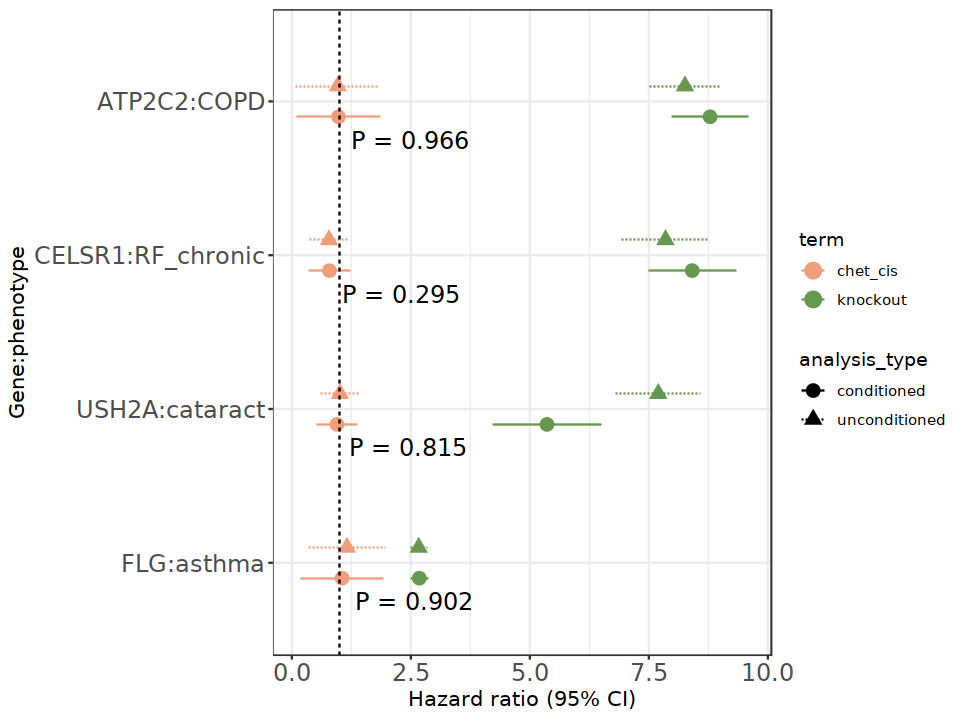

In [34]:
# subset genes in which we have sufficient cis to test/plot ---
forest_dat_subset <- bind_rows(uncond, cond) 
forest_dat_subset$hgnc_symbol <- mapping[forest_dat_subset$gene]
forest_dat_subset <- forest_dat_subset %>%
  filter(test_combo %in% combos_plot & term %in% c("chet_cis","knockout")) %>%
  filter(diagnosis %in% c("RF_chronic","COPD","asthma","cataract")) %>% 
  filter(hgnc_symbol %in% c("USH2A","ATP2C2", "FLG", "CELSR1")) %>%
  mutate(lci = estimate - 1.96*std.error,
         uci = estimate + 1.96*std.error,
         analysis_type = factor(analysis_type, levels = c("conditioned", "unconditioned")),
         plabel = paste0("P = ", gsub("e", "E", signif(p.value, digits = 3))),
         print_combo = factor(paste0(hgnc_symbol, ":", diagnosis), 
                              levels = for_ordering$print_combo))

# only display conditional P-value
forest_dat_subset$plabel[forest_dat_subset$analysis_type == "unconditioned"] <- NA

# plot them
options(repr.plot.width=8, repr.plot.height=6)
pd <- position_dodge(width = 0.4)
res_plot_subset <- ggplot(forest_dat_subset, aes(x = estimate, y = print_combo,
                                   group = analysis_type, label=plabel)) +
  geom_pointrange(aes(xmin = lci, xmax = uci,
                      shape = analysis_type, color = term,
                      linetype = analysis_type, size = 4.5),
                  position = pd,
                  size = 0.8) +
  geom_text_repel(data = subset(forest_dat_subset, forest_dat_subset$term == "chet_cis"),
                  size = 5, direction = "x", nudge_y=-0.25, nudge_x=1.5, color = 'black', segment.color = NA) +
  geom_vline(xintercept = 1, linetype = 2) +
  scale_color_manual(values = custom_col_pal) +
  scale_x_continuous(guide = guide_axis(check.overlap = TRUE)) +
  labs(x = "Hazard ratio (95% CI)", y = "Gene:phenotype") +
  theme(axis.title = element_text(size = 12),
        axis.text.x = element_text(size = 14),
        axis.text.y = element_text(size = 14))

res_plot_subset
#forest_dat_subset

In [56]:
table(forest_dat$term)


chet_cis knockout       wt 
      34       34       34 

In [57]:
# get how many knockouts we have per 
cat_per_combo <- do.call(rbind, lapply(forest_dat$test_combo[forest_dat$term == "knockout"], function(id){
    splitted <- unlist(strsplit(id, split = ":"))
    gene <- splitted[1]
    pheno <- splitted[2]
    d <- extract_knockout_counts(pheno, gene, samples, phenotypes)
    d$combo <- id
    return(d)
}))

In [59]:
#cat_by_cases <- cat_per_combo #[cat_per_combo$affected=="cases",]
#cat_by_cases$label <- paste0(cat_by_cases$is_chet, "/", cat_by_cases$is_hom)
#cat_by_cases$hgnc_symbol <- mapping[cat_by_cases$gene]
#cat_by_cases <- cat_by_cases[cat_by_cases$phenotype %in% c("RF_chronic","COPD","asthma","cataract"),]
#cat_by_cases <- cat_by_cases[cat_by_cases$hgnc_symbol %in% c("USH2A","ATP2C2", "FLG", "CELSR1"),]
#cat_by_cases

#cat_by_cases[cat_by_cases$phenotype %in% c("CC","hearing_loss"),]
#cat_by_cases[,]
#cat_by_cases <- cat_by_cases[,c("combo","label")]
#forest_dat_cases <- merge(forest_dat[term == "", cat_by_cases)
#forest_dat_cases
#cat_by_cases

### Kaplan Meier

In [70]:
library(survival)
library(survminer)
library(broom)
library(tidyverse)
library(RColorBrewer)
library(ggpubr)
library(ggrepel)
theme_set(theme_bw())



Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma




In [71]:
# Read results tables ----

surv_dat <- 
  readRDS("/well/lindgren-ukbb/projects/ukbb-11867/samvida/general_resources/eid_survival_dat_all_phenotypes.rds")

dat <- read.table("/well/lindgren-ukbb/projects/ukbb-11867/samvida/for_fred_ko_project/2212_analyses/results/all_coxph_results.txt",
                  sep = "\t", header = T, stringsAsFactors = F, quote = "", 
                  comment.char = "$")
dat <- dat %>% 
  mutate(test_combo = paste0(gene, ":", diagnosis))

source("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/scripts/post_hoc/utils.R")
mapping <- get_mapping_ensembl_to_hgnc()
dat$hgnc_symbol <- mapping[dat$gene]

# Set multiple-testing thresholds 
unique_comb_tests <- unique(dat$test_combo)
PTHRESH <- 0.05/length(unique_comb_tests)

In [72]:
# Get list and locations of plots to re-run ----

signif_dat <- dat[dat$term == "knockout" & dat$p.value <= PTHRESH, 
                  c("gene", "diagnosis")]
# Annotate with gene-file location
list_of_files <- list.files("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/survival/knockouts/pLoF_damaging_missense/",
                            recursive = T)

signif_dat$input_dir <- sapply(signif_dat$gene, function (x) 
  list_of_files[grep(x, list_of_files)])

GENES <- unique(signif_dat$gene)
DIAGNOSES <- unique(signif_dat$diagnosis)


In [73]:
# Re-run KM plots for these combinations ----

# For better powered analysis
KOLEVELS <- c("het", "chet_cis", "knockout", "wt")

id_class <- lapply(GENES, function (g) {
  fname <- gzfile(paste0("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/survival/knockouts/pLoF_damaging_missense/",
                         signif_dat$input_dir[signif_dat$gene == g][1]),
                  "rt")
  res <- read.table(fname, header = T, stringsAsFactors = F,
                    sep = "\t", na.strings = "")[, c("eid", "annotation")]
  res <- res %>% 
    rename(group = annotation) %>% 
    mutate(group = ifelse(group == "hom" | group == "chet_trans", 
                          "knockout", group))
  
  res <- res %>% mutate(eid = as.character(eid),
                        group = factor(as.character(group),
                                       levels = KOLEVELS))
  return (res)
})
names(id_class) <- GENES

In [75]:
# Function to plot KM curves ----

custom_col_pal <- c("#B13F64", # dark red - hets
                    "#F09D7C", # orange - chet-cis
                    "#669850", # green - knockouts
                    "#2266AC") # blue - wildtype

custom_col_pal <- setNames(custom_col_pal, 
                           paste0("group=", KOLEVELS))

printKMPlot <- function (g, diag) {
  # Fit survival models
  df <- surv_dat[[diag]]
  df$eid <- as.character(df$eid)
  df <- inner_join(df, id_class[[g]], by = "eid")
  df <- df[complete.cases(df), ]
  
  fitted_dat <- survfit(Surv(age_at_first_record,
                             age_at_event,
                             event_observed) ~ group, data = df)
  
  to_print_wt <- tidy(fitted_dat) %>% filter(strata == "group=wt")
  if (all(to_print_wt$conf.high == 1)) {
    df <- df %>% filter(group != "wt")
    fitted_dat <- survfit(Surv(age_at_first_record,
                               age_at_event,
                               event_observed) ~ group, data = df)
  }
  
  surv_plot <- ggsurvplot(fit = fitted_dat,
                          data = df,
                          fun = "event",
                          conf.int = T, censor = F, size = 0.5,
                          palette = custom_col_pal,
                          ggtheme = theme_bw(),
                          xlab = "Age (years)", ylab = "Probability diagnosed",
                          legend = "none",
                          font.x = c(6), font.y = c(6),
                          font.tickslab = c(6),
                          font.family = "Helvetica")
  
  diag_name_tmp <- gsub("/", "_", diag)
  ggsave(paste0("derived/plots/samvida/pretty_plots/", 
                mapping[g], "_", diag_name_tmp, "_pretty.pdf"),
         units = "cm", width = 7.5, height = 5, dpi = 300,
         surv_plot$plot)
  
  for_label <- dat %>% filter(gene == g & diagnosis == diag) %>%
    mutate(add_text = paste0(gsub("group", "", term), ":",
                             " HR=", signif(estimate, 3), 
                             ", P=", signif(p.value, 3)))
  add_text <- paste0(for_label$add_text, collapse = "\n")
  
  res_plot <- surv_plot$plot +
    geom_label(data = data.frame(),
               aes(label = add_text, x = -Inf, y = Inf), 
               hjust = "inward", vjust = "inward", size = 2.5) 
  
  ggsave(paste0("derived/plots/samvida/pretty_plots/", 
                g, "_", diag_name_tmp, ".pdf"),
         units = "cm", width = 15, height = 10, dpi = 300,
         res_plot)
  return (res_plot)
}

In [4]:
#wlapply(1:nrow(signif_dat), function (i) {
#  printKMPlot(signif_dat$gene[i], signif_dat$diagnosis[i])
#})

In [ ]:
#d <- fread("data/conditional/common/spa_iter/")

In [20]:
setwd("/well/lindgren/flassen/projects/utrs/whiffin-rotation/")
#devtools::load_all("/well/lindgren/flassen/projects/utrs/whiffin-rotation/utrsRus.Rproj")

In [51]:
loeuf_path <- "/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv"
loeuf <- fread(loeuf_path)
loeuf <- loeuf[,c("gene","transcript","gene_id", "oe_lof_upper_bin")]
loeuf <- loeuf[!is.na(loeuf$oe_lof_upper_bin),]
loeuf$decile <- unlist(lapply(loeuf$oe_lof_upper_bin, function(l) paste0(l,"-",l+1)))
loeuf$decile <- factor(loeuf$decile, levels = paste0(0:9,'-',1:10))
loeuf_mapping <- loeuf$decile
names(loeuf_mapping) <- loeuf$transcript

In [67]:
obs <- fread('derived/run001/test5_observed_codons.csv', sep = ',')
files_expt <- list.files("derived/run001", pattern="expt_rep[0-9]+", full.names = TRUE)
obs$transcript <- gsub("\\.[0-9]+","", obs$enstid_version)
obs$loeuf <- loeuf_mapping[obs$transcript]
deciles <- na.omit(unique(obs$loeuf))

In [105]:
final <- do.call(rbind, lapply(deciles, function(dec){
    obs_decile <- obs[obs$loeuf %in% dec, ]
    final <- Reduce(merge, 
        lapply(files_expt, function(f){
            expt <- fread(f)
            expt_decile <- expt[expt$loeuf %in% dec, ]
            mrg <- merge(expt_decile, obs_decile)
            print(paste(nrow(expt_decile), "-", nrow(obs_decile)))
            obs <- mrg[,get('obs',mrg), with = F] 
            expt <- mrg[,get('expt',mrg), with = F] 
            d <- as.data.frame(colSums(obs) / colSums(expt))
            rep <- as.numeric(gsub("rep","",stringr::str_extract(f, "rep[0-9]+")))
            colnames(d) <- paste0('oe_rep',rep)
            d$codon <- unlist(lapply(strsplit(rownames(d), split = '\\.'), function(x) x[2]))
            d$decile <- dec
            return(d)
        })
    )
}))

[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1810 - 1810"
[1] "1739 - 1739"
[1] "1739 - 1739"
[1] "1739 - 1739"
[1] "1739 - 1739"
[1] "1739 - 1739"
[1] "1739 

In [539]:
# get confidence intervals
final_with_ci <- data.table(
    codon = final$codon,
    decile = final$decile,
    lower = apply(final[,grepl("oe", colnames(final))], 1, quantile, probs = 0.001),
    estimate = apply(final[,grepl("oe", colnames(final))], 1, quantile, probs = 0.50),
    upper = apply(final[,grepl("oe", colnames(final))], 1, quantile, probs = 0.999)
)

In [540]:
vars <- aggregate(estimate ~ codon, data=final_with_ci, FUN=var)
vars <- vars[rev(order(vars$estimate)),]
means <- aggregate(estimate ~ codon, data=final_with_ci, FUN=mean)
means <- means[rev(order(means$estimate)),]

codons_to_plot <- unique(c("ATG", head(vars$codon, n = 3), tail(means$codon, n = 3), head(means$codon, n = 3)))

In [541]:
final_with_ci <- final_with_ci[final_with_ci$codon %in% codons_to_plot,]

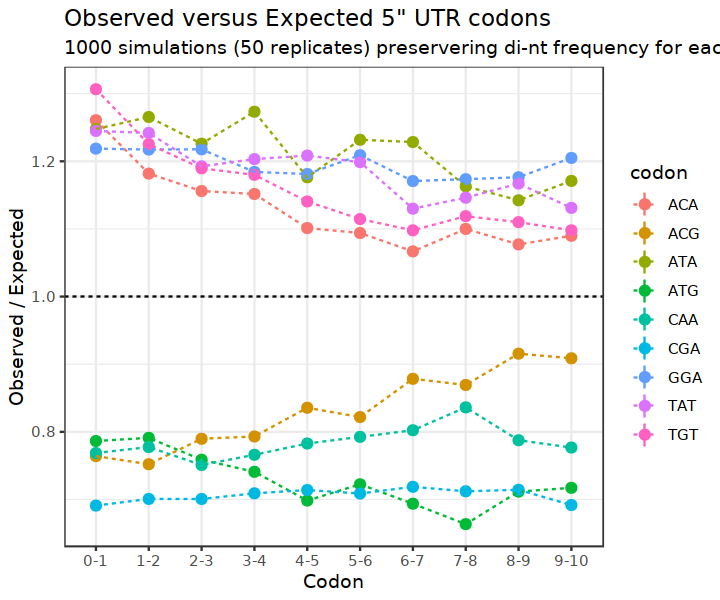

In [542]:
options(repr.plot.width=6, repr.plot.height=5)
ggplot(final_with_ci, aes(x=decile, y = estimate, ymax=upper,ymin=lower, color=codon, group=codon)) +
    geom_pointrange(size = 0.4) +
    geom_line(linetype = 'dashed') +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    ggtitle('Observed versus Expected 5" UTR codons',
          '1000 simulations (50 replicates) preservering di-nt frequency for each sequence') +
    ylab('Observed / Expected') +
    xlab('Codon') +
    theme_bw()
    #facet_grid(decile~1)

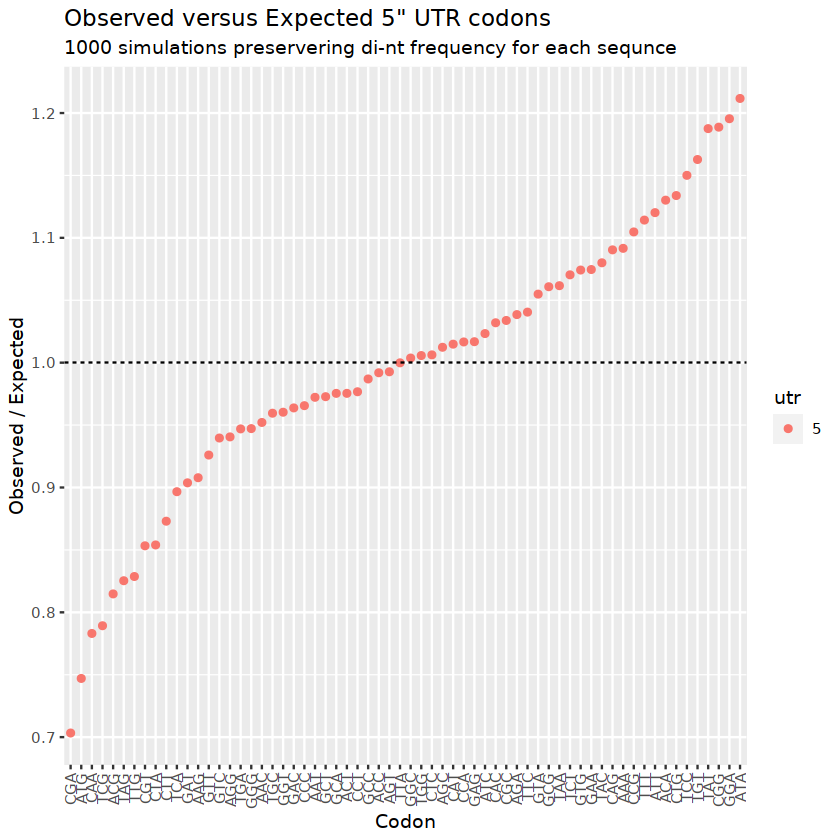

In [22]:

# plot data


### Co-occurence

In [4]:
# get knockouts
kos <- read_ukb_wes_kos(annotation = "pLoF_damaging_missense")
colnames(kos)[colnames(kos) == "gene_id"] <- "ensembl_gene_id"

s,ensembl_gene_id,transcript_id,varid,gts,AC,AF,AN,hom_alt_n,phased.a1,phased.a2,unphased.n,pKO,knockout,consequence_category,most_severe_consequence,revel_score,cadd_phred,exon,intron
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1008716,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,0|1,571,0.0016168,353174,0,0,1,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1017844,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,1|0,571,0.0016168,353174,0,1,0,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1018695,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,0|1,571,0.0016168,353174,0,0,1,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1020249,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,0|1,571,0.0016168,353174,0,0,1,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1025619,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,1|0,571,0.0016168,353174,0,1,0,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1039712,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,0|1,571,0.0016168,353174,0,0,1,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1047133,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,0|1,571,0.0016168,353174,0,0,1,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1049496,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,0|1,571,0.0016168,353174,0,0,1,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA
1052591,ENSG00000000457,ENST00000367772,chr1:169876054:A:G,0|1,571,0.0016168,353174,0,0,1,0,0,Heterozygote,damaging_missense,missense_variant,0.815,27.1,4/14,NA


### Permute things

In [67]:
source("scripts/post_hoc/utils.R")

In [73]:
args <- list(
    path_hits_to_analyze = "data/post_hoc/results/165k_saige_cond_sig_subset_prefer_prs.txt.gz",
    path_phenotypes ="data/phenotypes/dec22_phenotypes_binary_200k.tsv.gz"
)

In [74]:
# get phenotyoes
phenotype_df <- fread(args$path_phenotypes)

In [75]:
# get gene_phenotype
gene_phenotype <- fread(args$path_hits_to_analyze)
gene_phenotype$phenotype <- gsub("chr[0-9]+\\_","",gene_phenotype$phenotype)
gene_phenotype <- gene_phenotype[gene_phenotype$p.value < (0.05 / (313 * 1143)),]
gene_phenotype <- gene_phenotype[gene_phenotype$N_ko_case >= 2]
gene_phenotype <- gene_phenotype[,1:3]
gene_phenotype <- gene_phenotype[!duplicated(gene_phenotype),]

In [95]:
# get knockouts
kos <- read_ukb_wes_kos(annotation = "pLoF_damaging_missense")
colnames(kos)[colnames(kos) == "gene_id"] <- "ensembl_gene_id"

In [134]:
kos$is_cis <- kos$knockout == "Compound heterozygote (cis)"
kos$is_chet <- kos$knockout == "Compound heterozygote"
kos$is_hom <- kos$knockout == "Homozygote"

In [143]:
lst <- lapply(1:nrow(kos), function(ixd) {
    phenotype <- gene_phenotype$phenotype[idx]
    gene <- gene_phenotype$MarkerID[idx]
    # get case controls with knockouts
    eid_case <- unique(phenotype_df$eid[phenotype_df[[phenotype]]])
    eid_ctrl <- unique(phenotype_df$eid[!phenotype_df[[phenotype]]])
    # only use gene-phenotype relationships that are previously significant
    kos_case_ctrl <- kos[(kos$ensembl_gene_id %in% gene) & (kos$s %in% c(eid_case, eid_ctrl))]
    kos_case_ctrl$case <- (kos_case_ctrl$s %in% eid_case)
    # combine them to stratify case/ctrl by knockout type
    aggr_chet <- data.table(aggregate(is_chet ~ case, data = kos_case_ctrl, FUN=sum))
    aggr_cis <- data.table(aggregate(is_cis ~ case, data = kos_case_ctrl, FUN=sum))
    aggr_hom <- data.table(aggregate(is_hom ~ case, data = kos_case_ctrl, FUN=sum))
    # merge and return
    combined <- Reduce(merge, list(aggr_chet, aggr_cis, aggr_hom))
    combined$gene <- gene
    combined$phenotype <- phenotype
    return(combined)  
})

In [142]:
d <- do.call(rbind, lst)

case,is_chet,is_cis,is_hom
<lgl>,<int>,<int>,<int>
FALSE,1,21,4
TRUE,0,1,2


In [109]:
table(kos$knockout)


      Compound heterozygote Compound heterozygote (cis) 
                      11967                       80362 
               Heterozygote                  Homozygote 
                    6897864                      544679 

In [ ]:
phenotype_df <- fread(args$path_phenotypes)

In [ ]:
d <- fread(args$path_hits_to_analyze)
d$phenotype <- gsub("chr[0-9]+\\_","",d$phenotype)
d <- d[d$p.value < (0.05 / (313 * 1143)),]
d <- d[d$N_ko_case >= 2]
d <- d[,1:3]
d <- d[!duplicated(d),]

In [71]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")
dt_subset <- dt[dt$annotation %in% c("pLoF_damaging_missense"), ]
#aggr_chet <- aggregate(is_chet ~ ensembl_gene_id + ensembl_transcript_id + annotation, data = dt_subset, FUN=sum)
#aggr_cis <- aggregate(is_cis ~ ensembl_gene_id + ensembl_transcript_id + annotation, data = dt_subset, FUN=sum)
#aggr_hom <- aggregate(is_hom ~ ensembl_gene_id + ensembl_transcript_id + annotation, data = dt_subset, FUN=sum)
#aggr <- merge(aggr_chet, aggr_hom, all = TRUE)
#aggr <- merge(aggr, aggr_cis, all = TRUE)
#aggr$is_ko <- aggr$is_chet + aggr$is_hom

ensembl_gene_id,ensembl_transcript_id,annotation,is_chet,is_hom,is_cis,is_ko
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
ENSG00000001036,ENST00000002165,pLoF_damaging_missense,0,0,4,0
ENSG00000001461,ENST00000374399,pLoF_damaging_missense,0,0,2,0
ENSG00000001626,ENST00000003084,pLoF_damaging_missense,114,4,22,118
ENSG00000001630,ENST00000003100,pLoF_damaging_missense,0,0,6,0
ENSG00000003756,ENST00000347869,pLoF_damaging_missense,0,0,1,0
ENSG00000003989,ENST00000004531,pLoF_damaging_missense,14,5,3,19
ENSG00000004139,ENST00000585482,pLoF_damaging_missense,0,2,0,2
ENSG00000004455,ENST00000354858,pLoF_damaging_missense,0,0,2,0
ENSG00000004700,ENST00000444129,pLoF_damaging_missense,3,0,0,3


In [157]:
getwd()

[1] "/gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb"

[1] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_AD_combined_pLoF_damaging_missense.txt.gz"                                                             
  [2] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_BC_combined_pLoF_damaging_missense.txt.gz"                                                             
  [3] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_BC_combined_pLoF_damaging_missense_locoprs.txt.gz"                                                     
  [4] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CAD_combined_pLoF_damaging_missense.txt.gz"                                                            
  [5] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CC_combined_pLoF_damaging_missense.txt.gz"                                                             
  [6] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CC_combined_pLoF_damaging_missense_locoprs.txt.gz"                                                     
  [7] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CD_combined_pLoF_damaging_missense.txt.gz"                                                             
  [8] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CD_combined_pLoF_damaging_missense_locoprs.txt.gz"                                                     
  [9] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CIRR_combined_pLoF_damaging_missense.txt.gz"                                                           
 [10] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CIRR_combined_pLoF_damaging_missense_locoprs.txt.gz"                                                   
 [11] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CLD_combined_pLoF_damaging_missense.txt.gz"                                                            
 [12] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_CLD_combined_pLoF_damaging_missense_locoprs.txt.gz"                                                    
 [13] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_COPD_combined_pLoF_damaging_missense.txt.gz"                                                           
 [14] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_COPD_combined_pLoF_damaging_missense_locoprs.txt.gz"                                                   
 [15] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_DEM_combined_pLoF_damaging_missense.txt.gz"                                                            
 [16] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_DEM_combined_pLoF_damaging_missense_locoprs.txt.gz"                                                    
 [17] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_DEP_combined_pLoF_damaging